In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
# Загрузка данных
df = pd.read_csv("train.csv")
print("Размер датафрейма:", df.shape)
df.head()

Размер датафрейма: (9000, 23)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,...,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,...,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,...,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,...,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,...,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,...,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


## Разведочный анализ данных (EDA)

In [3]:
# Общая информация и пропуски
df.info()

missing = df.isnull().sum()
print("\nКоличество пропусков по колонкам:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")
print("\nВсего пропусков:", df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       9000 non-null   int64  
 1   eeg_delta_power          9000 non-null   float64
 2   eeg_theta_power          9000 non-null   float64
 3   eeg_alpha_power          9000 non-null   float64
 4   eeg_sigma_power          9000 non-null   float64
 5   eeg_beta_power           9000 non-null   float64
 6   eeg_gamma_power          9000 non-null   float64
 7   eeg_slow_osc_power       9000 non-null   float64
 8   eeg_spectral_entropy     9000 non-null   float64
 9   eeg_spindle_density      9000 non-null   float64
 10  eeg_kcomplex_rate        9000 non-null   float64
 11  emg_chin_tone            9000 non-null   float64
 12  emg_tone_variance        9000 non-null   float64
 13  eog_movement_density     9000 non-null   float64
 14  eog_amplitude            9000 non-n

In [4]:
# Распределение целевой переменной sleep_stage
counts = df["sleep_stage"].value_counts().sort_index()
percent = df["sleep_stage"].value_counts(normalize=True).sort_index() * 100

dist = pd.DataFrame({"count": counts, "percent": percent.round(2)})
print(dist)

# Оценка сбалансированности
imbalance_ratio = counts.max() / counts.min()
print(f"\nСоотношение самого крупного к самому мелкому классу: {imbalance_ratio:.2f}")

             count  percent
sleep_stage                
0             2001    22.23
1             2442    27.13
2             2237    24.86
3             2320    25.78

Соотношение самого крупного к самому мелкому классу: 1.22


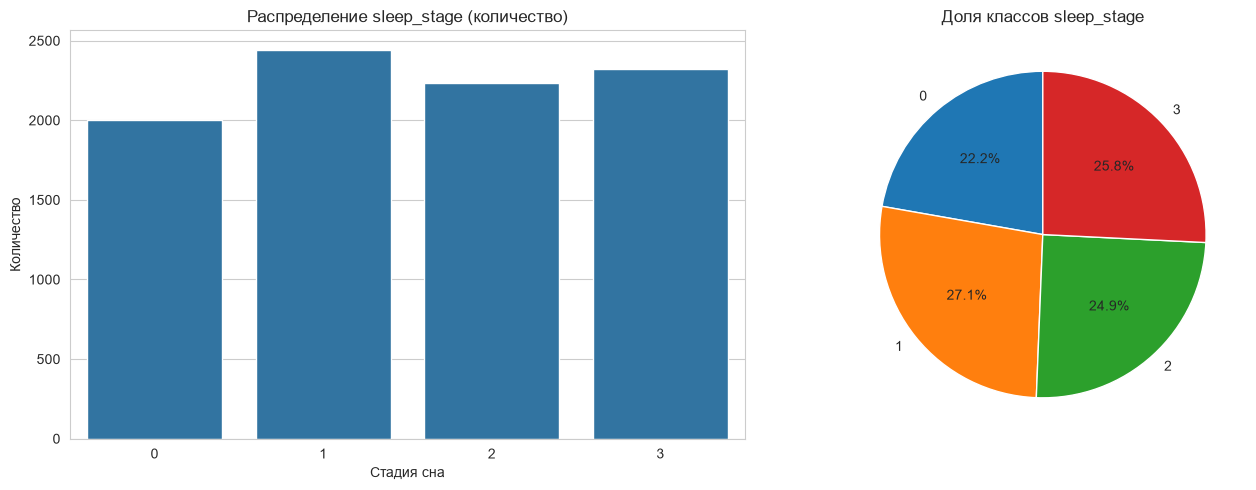

In [5]:
# Визуализация распределения классов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="sleep_stage", data=df, order=counts.index, ax=axes[0])
axes[0].set_title("Распределение sleep_stage (количество)")
axes[0].set_xlabel("Стадия сна")
axes[0].set_ylabel("Количество")

axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Доля классов sleep_stage")

plt.tight_layout()
plt.show()

In [6]:
df.describe()

,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,...,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,4499.000000,9000.000000
mean,4499.500000,-0.015335,-0.034072,-0.016476,0.012123,-0.009634,-0.010607,-0.014176,0.010259,0.006484,...,0.021517,-0.006761,0.004582,-0.021423,0.033799,-0.001568,0.010621,-0.020689,-0.010257,1.541778
std,2598.220545,2.431299,2.408445,5.042238,2.206821,2.882702,2.427740,2.801109,2.753279,2.174239,...,2.705402,2.493104,1.975924,2.528445,2.935356,2.345418,2.061752,1.974260,1.037927,1.099369
min,0.000000,-9.567380,-8.276530,-20.632490,-7.947840,-11.459950,-9.637800,-14.122600,-9.301290,-8.828190,...,-10.835050,-9.614650,-7.160240,-9.543670,-11.996570,-9.021170,-8.704410,-6.939570,-3.936310,0.000000
25%,2249.750000,-1.688420,-1.649095,-3.465228,-1.459777,-1.962703,-1.651817,-1.873387,-1.858893,-1.484435,...,-1.792410,-1.687935,-1.317998,-1.733223,-1.957965,-1.590263,-1.371770,-1.355550,-0.718165,1.000000
50%,4499.500000,-0.012190,-0.019775,0.018740,-0.001480,0.005230,0.009700,0.022685,-0.028000,0.023765,...,0.019475,-0.000230,0.003665,-0.023485,0.013430,0.031125,0.005595,-0.005930,-0.002200,2.000000
75%,6749.250000,1.622143,1.603865,3.418938,1.512295,1.956398,1.634555,1.866453,1.881628,1.479208,...,1.824498,1.671345,1.355470,1.650858,2.041182,1.597958,1.405883,1.307837,0.691530,3.000000
max,8999.000000,8.797570,9.222480,18.869590,9.603400,10.026940,8.296140,10.362190,10.159880,8.937490,...,11.471740,10.285870,7.215020,9.895200,11.664360,9.010520,7.565330,6.690040,3.935860,3.000000


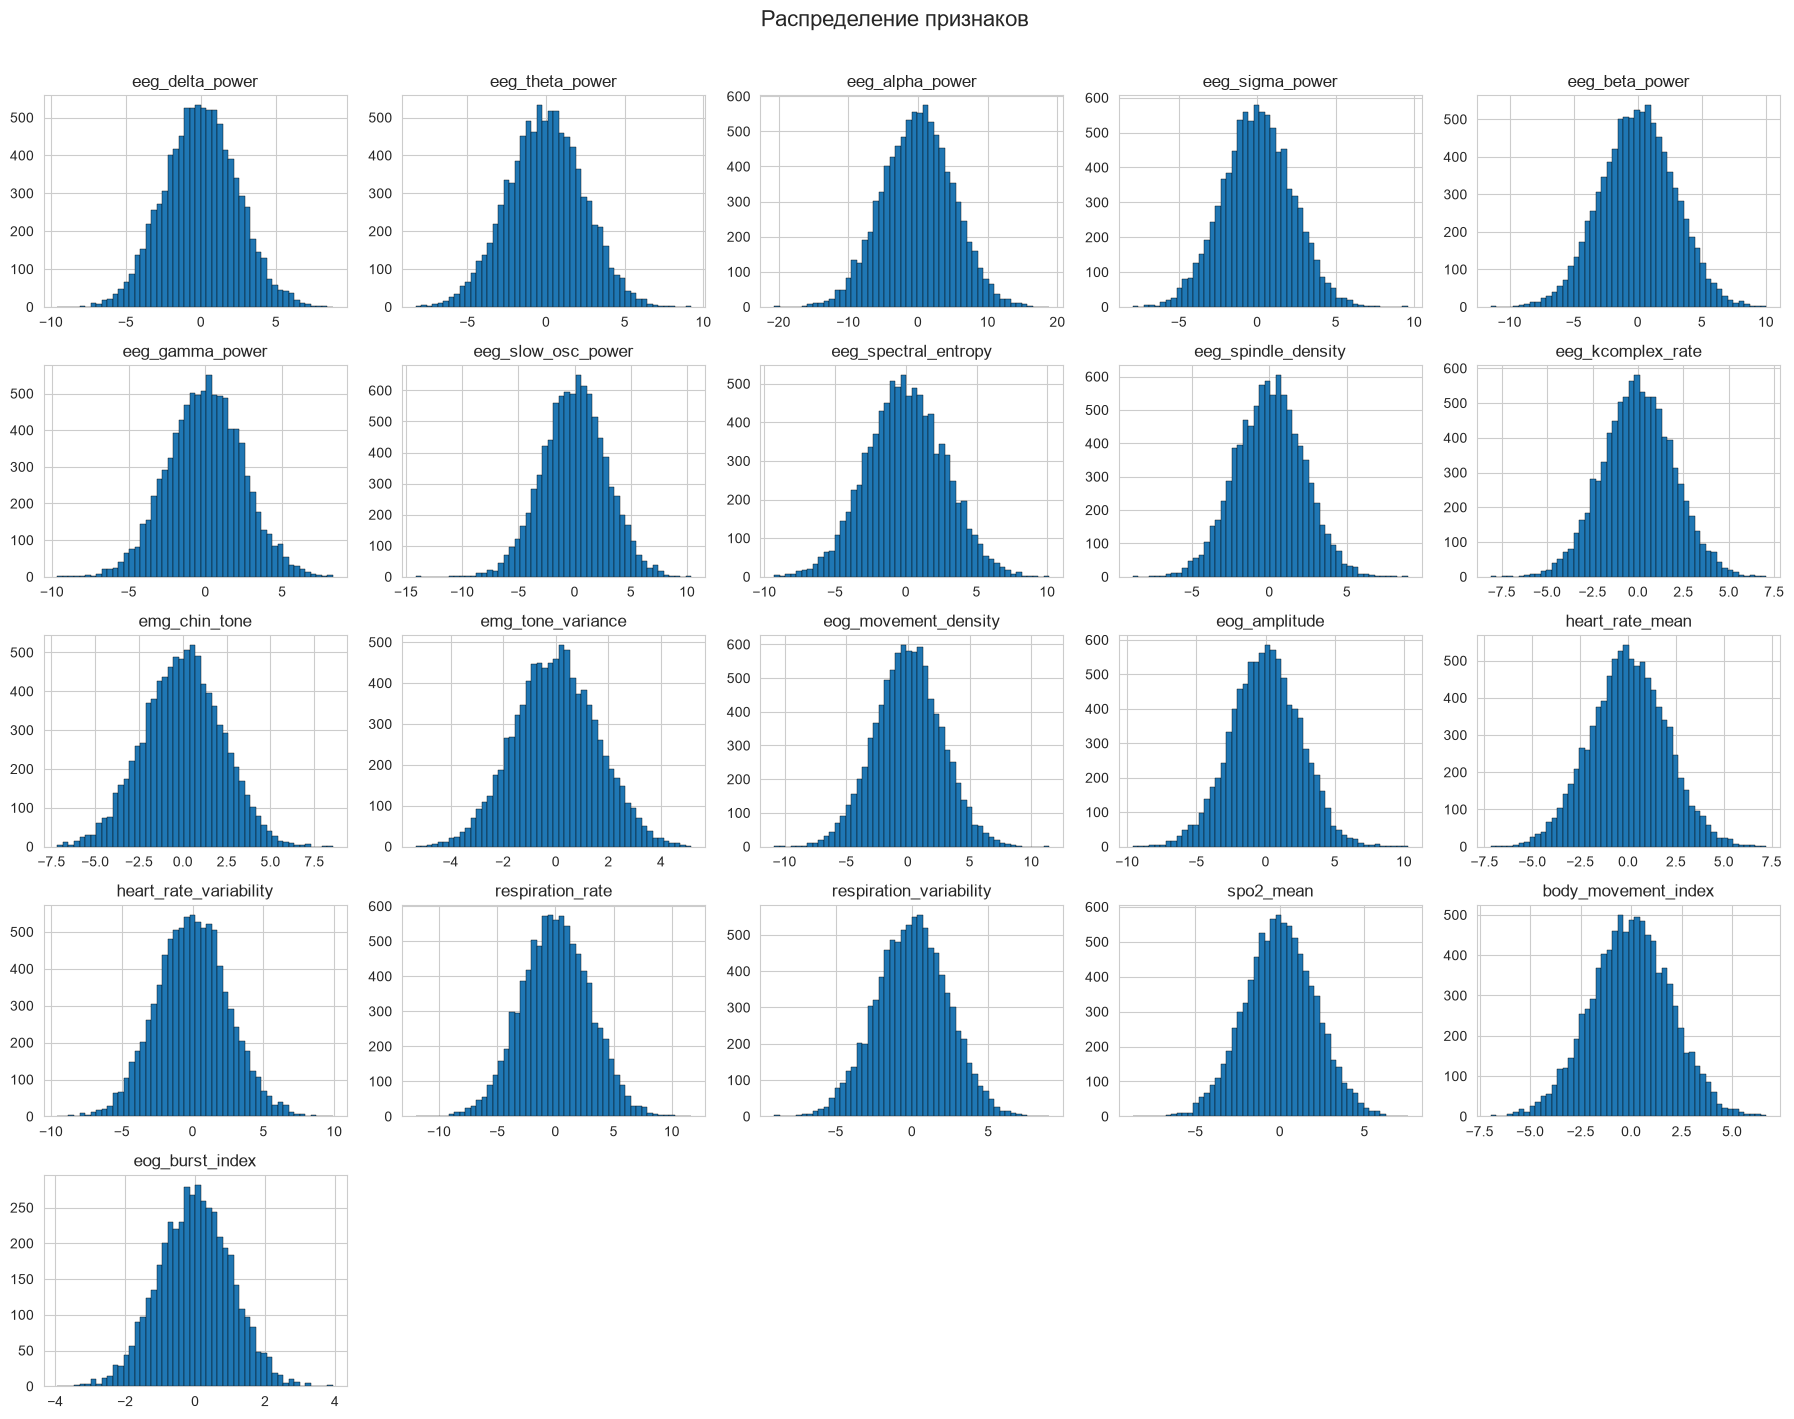

In [7]:
# Гистограммы распределения всех признаков
feature_cols = [c for c in df.columns if c not in ["id", "sleep_stage"]]

df[feature_cols].hist(bins=50, figsize=(18, 14), edgecolor="black", linewidth=0.3)
plt.suptitle("Распределение признаков", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

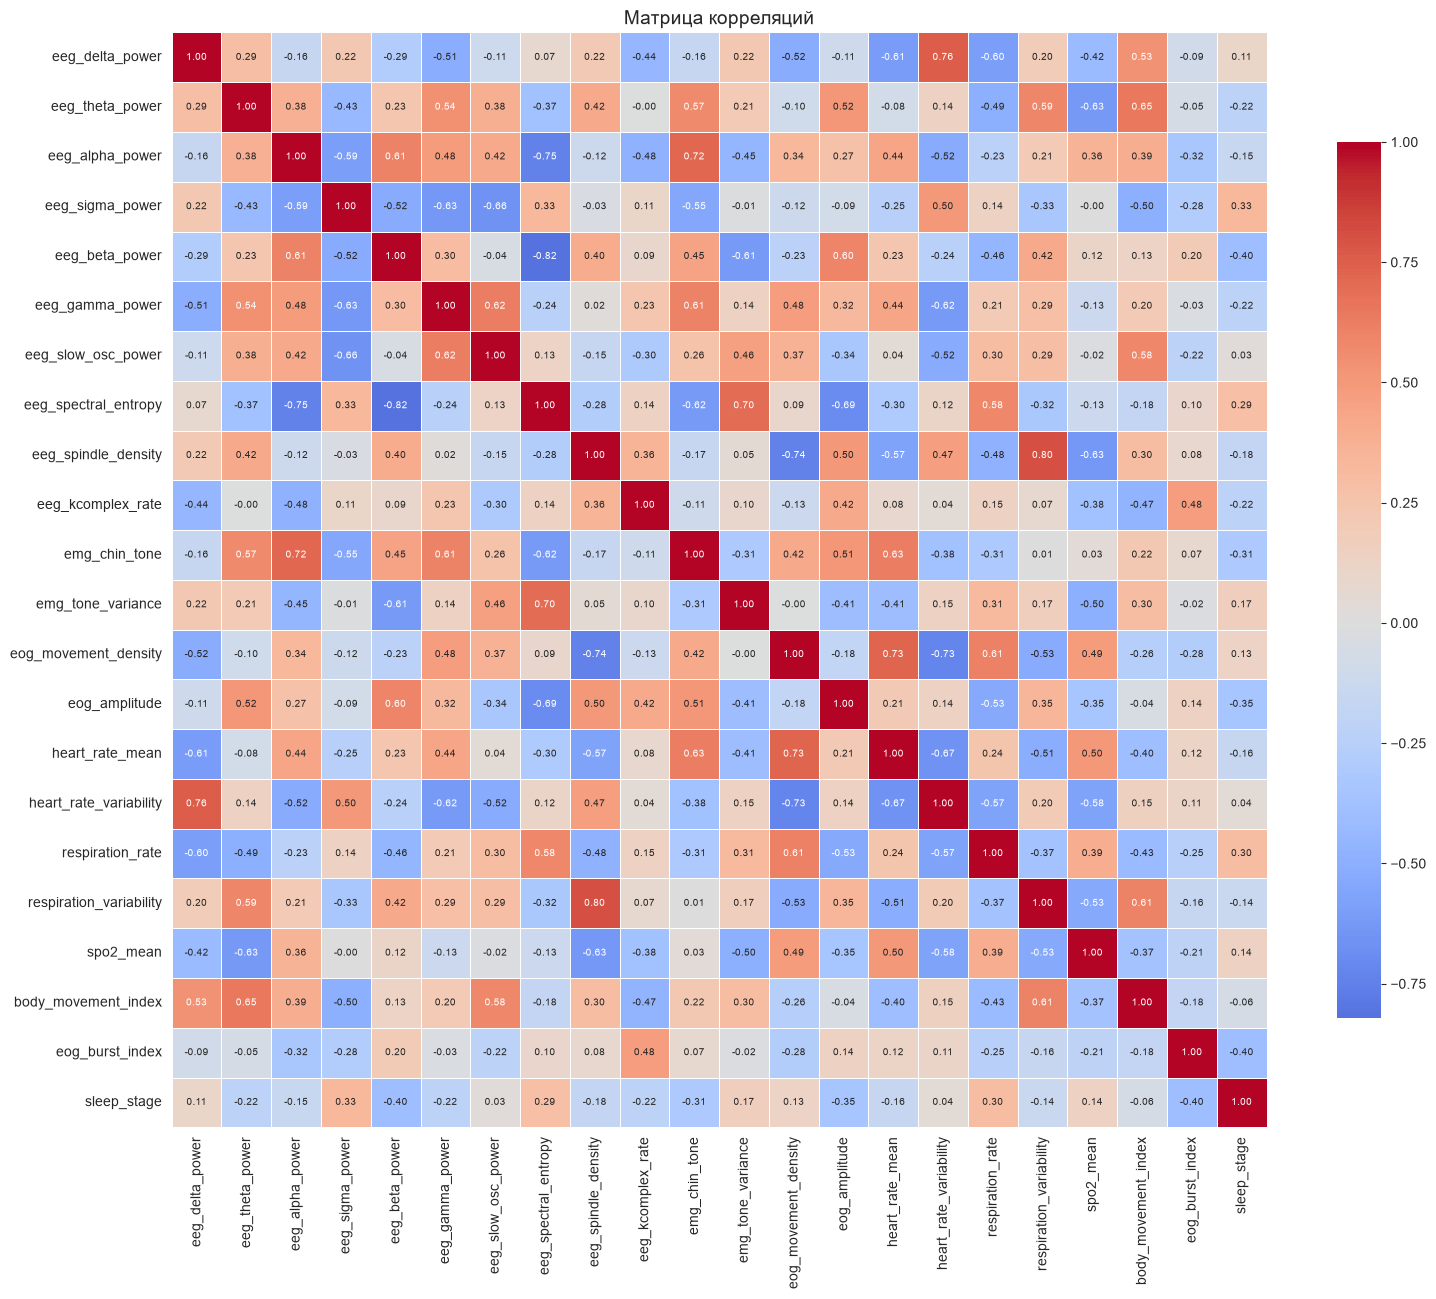

Корреляция признаков с sleep_stage (по модулю, по убыванию):
eog_burst_index            0.400307
eeg_beta_power             0.397909
eog_amplitude              0.346517
eeg_sigma_power            0.332914
emg_chin_tone              0.310506
respiration_rate           0.296791
eeg_spectral_entropy       0.286842
eeg_theta_power            0.223005
eeg_kcomplex_rate          0.220374
eeg_gamma_power            0.217018
eeg_spindle_density        0.179281
emg_tone_variance          0.168941
heart_rate_mean            0.160211
eeg_alpha_power            0.147412
spo2_mean                  0.142773
respiration_variability    0.135238
eog_movement_density       0.128105
eeg_delta_power            0.105518
body_movement_index        0.059120
heart_rate_variability     0.040136
eeg_slow_osc_power         0.026989
Name: sleep_stage, dtype: float64


In [8]:
# Heatmap корреляций (признаки + целевая переменная)
corr = df.drop(columns=["id"]).corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})
plt.title("Матрица корреляций", fontsize=14)
plt.tight_layout()
plt.show()

# Корреляция признаков с целевой переменной
print("Корреляция признаков с sleep_stage (по модулю, по убыванию):")
print(corr["sleep_stage"].drop("sleep_stage").abs().sort_values(ascending=False))

## Анализ пропусков в eog_burst_index

Проверим, отличаются ли строки с пропуском в `eog_burst_index` от строк без пропуска — по распределению признаков и по целевой переменной. Если отличий нет, пропуск можно считать случайным (MCAR); если есть — пропуск информативен и стоит добавить флаг `eog_burst_index_isna`.

Доля sleep_stage (%) в группах:
sleep_stage               0      1      2      3
eog_burst_index_isna                            
False                 22.87  27.34  24.65  25.14
True                  21.60  26.93  25.06  26.42


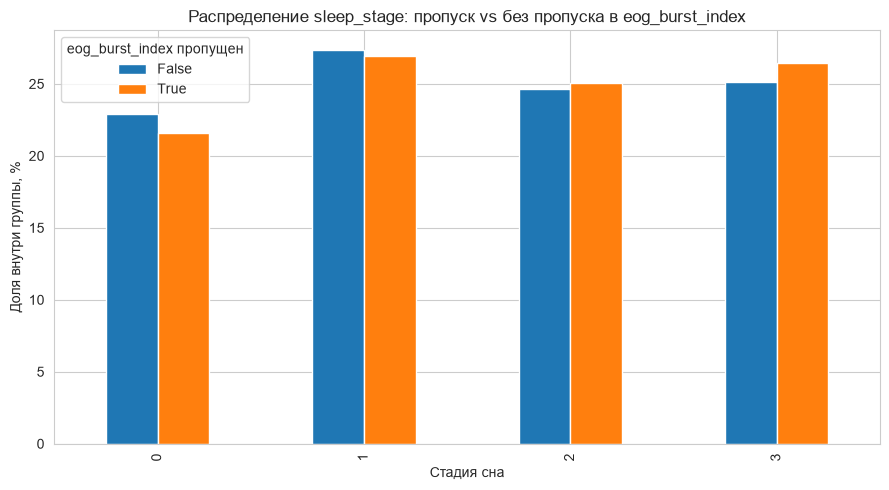

In [9]:
# Флаг пропуска и сравнение распределения целевой переменной
df["eog_burst_index_isna"] = df["eog_burst_index"].isna()

# Распределение sleep_stage в группах с пропуском и без
stage_by_missing = pd.crosstab(
    df["eog_burst_index_isna"], df["sleep_stage"], normalize="index"
) * 100
print("Доля sleep_stage (%) в группах:")
print(stage_by_missing.round(2))

plt.figure(figsize=(9, 5))
stage_by_missing.T.plot(kind="bar", ax=plt.gca())
plt.title("Распределение sleep_stage: пропуск vs без пропуска в eog_burst_index")
plt.xlabel("Стадия сна")
plt.ylabel("Доля внутри группы, %")
plt.legend(title="eog_burst_index пропущен")
plt.tight_layout()
plt.show()

Средние признаков по группам (отсортировано по |разнице|):
                         без пропуска  с пропуском  разница
eeg_alpha_power                 0.057       -0.090   -0.147
eeg_beta_power                  0.053       -0.073   -0.126
eeg_spectral_entropy           -0.048        0.068    0.116
eog_amplitude                   0.041       -0.055   -0.096
emg_chin_tone                   0.008       -0.053   -0.060
respiration_rate                0.005        0.063    0.059
eog_movement_density           -0.002        0.045    0.047
eeg_gamma_power                 0.013       -0.034   -0.046
emg_tone_variance              -0.020        0.021    0.041
heart_rate_mean                 0.024       -0.015   -0.039
eeg_sigma_power                -0.007        0.031    0.038
eeg_theta_power                -0.016       -0.052   -0.037
heart_rate_variability         -0.032       -0.011    0.021
eeg_slow_osc_power             -0.024       -0.004    0.021
eeg_delta_power                -0.025    

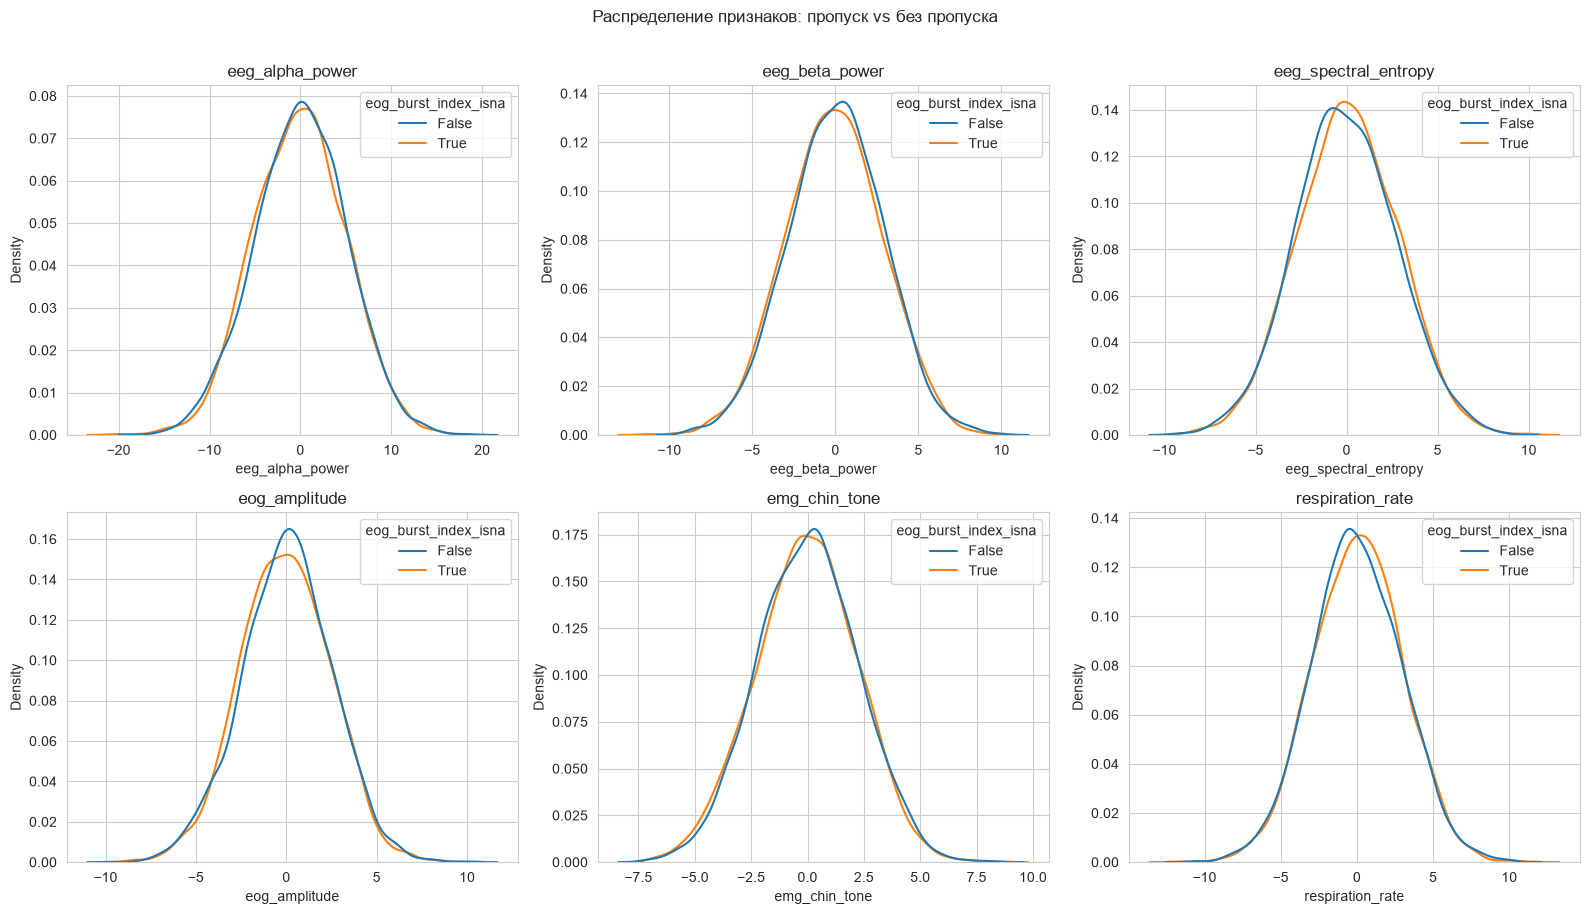

In [10]:
# Сравнение средних значений признаков в двух группах
compare_cols = [c for c in feature_cols if c != "eog_burst_index"]
group_means = df.groupby("eog_burst_index_isna")[compare_cols].mean().T
group_means.columns = ["без пропуска", "с пропуском"]
group_means["разница"] = (group_means["с пропуском"] - group_means["без пропуска"])
print("Средние признаков по группам (отсортировано по |разнице|):")
print(group_means.reindex(group_means["разница"].abs().sort_values(ascending=False).index).round(3))

# Визуальное сравнение распределений топ-признаков по различию средних
top_diff = group_means["разница"].abs().sort_values(ascending=False).head(6).index
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), top_diff):
    sns.kdeplot(data=df, x=col, hue="eog_burst_index_isna", common_norm=False, ax=ax)
    ax.set_title(col)
plt.suptitle("Распределение признаков: пропуск vs без пропуска", y=1.01)
plt.tight_layout()
plt.show()

## Полезность признаков

Сравним признаки по трём метрикам: линейная корреляция (Pearson), взаимная информация (ловит нелинейные связи) и важность из LightGBM (gain). Усреднённый ранг даёт устойчивую оценку.

                          corr     MI  lgbm_gain  rank_corr  rank_MI  rank_lgbm_gain  avg_rank
eog_burst_index          0.400  0.191       2637        1.0      2.0             2.0     1.667
eeg_sigma_power          0.333  0.131       2885        4.0      6.0             1.0     3.667
respiration_rate         0.297  0.133       2428        6.0      5.0             4.0     5.000
eeg_beta_power           0.398  0.116       1984        2.0      9.0             7.0     6.000
eeg_alpha_power          0.147  0.158       2569       14.0      4.0             3.0     7.000
emg_chin_tone            0.311  0.106       1741        5.0     10.0             8.0     7.667
eog_movement_density     0.128  0.179       1678       17.0      3.0             9.0     9.667
eeg_kcomplex_rate        0.220  0.087       2075        9.0     16.0             5.0    10.000
eeg_gamma_power          0.217  0.130       1448       10.0      7.0            13.0    10.000
eeg_spectral_entropy     0.287  0.100       1456  

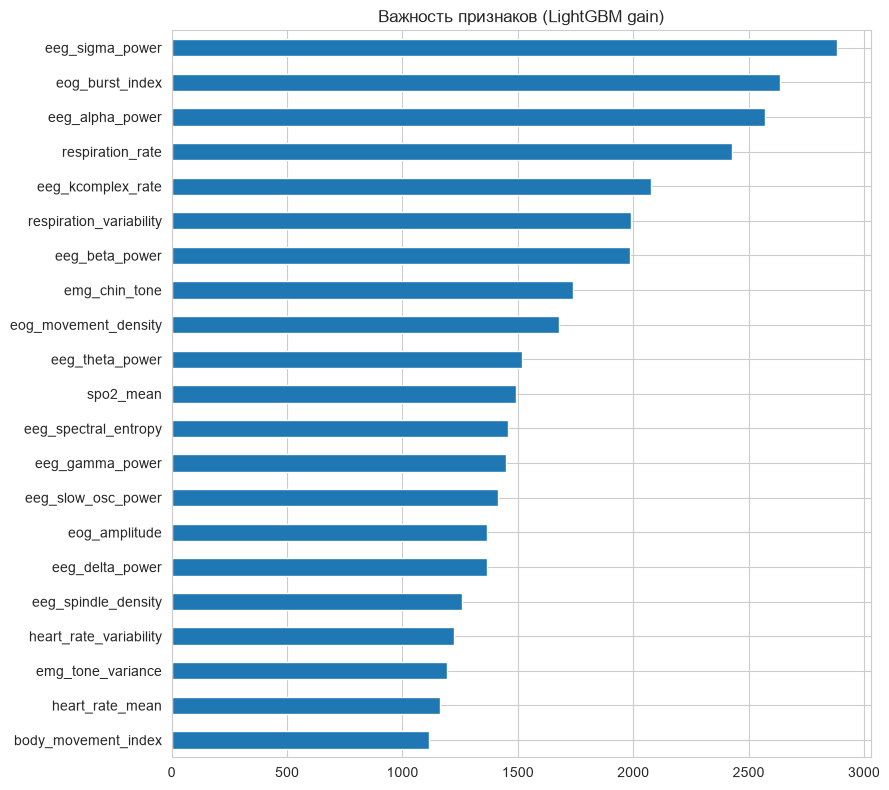

In [11]:
from sklearn.feature_selection import mutual_info_classif

y = df["sleep_stage"]
X = df[feature_cols]

# 1) Линейная корреляция с целевой
corr_target = df[feature_cols + ["sleep_stage"]].corr()["sleep_stage"].drop("sleep_stage").abs()

# 2) Взаимная информация (импутируем медианой только для расчёта MI)
mi = pd.Series(
    mutual_info_classif(X.fillna(X.median()), y, random_state=0),
    index=feature_cols,
)

# 3) Важность из LightGBM (NaN обрабатывает нативно)
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=0, verbose=-1)
lgbm.fit(X, y)
gain = pd.Series(lgbm.feature_importances_, index=feature_cols)

# Сводная таблица с усреднённым рангом
imp_table = pd.DataFrame({"corr": corr_target, "MI": mi, "lgbm_gain": gain})
for col in ["corr", "MI", "lgbm_gain"]:
    imp_table[f"rank_{col}"] = imp_table[col].rank(ascending=False)
imp_table["avg_rank"] = imp_table[[c for c in imp_table.columns if c.startswith("rank_")]].mean(axis=1)
imp_table = imp_table.sort_values("avg_rank")
print(imp_table.round(3).to_string())

# Визуализация важности LightGBM
gain.sort_values().plot(kind="barh", figsize=(9, 8))
plt.title("Важность признаков (LightGBM gain)")
plt.tight_layout()
plt.show()

## Подготовка данных и Pipeline

Формируем `X`/`y`, делаем train/val split со стратификацией (классы почти сбалансированы, но stratify сохранит пропорции). Метрика — **macro-F1** (усреднение F1 по всем 4 классам с равным весом).

Pipeline: `SimpleImputer (median) → StandardScaler → model`. Импутация нужна, потому что масштабирование не работает с NaN, а StandardScaler требуется для моделей, чувствительных к масштабу (линейные, KNN, SVM). Для бустингов масштабирование безвредно, но можно использовать модель напрямую.

In [12]:
# Дополнительные импорты для пайплайна
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer

# Признаки и целевая переменная (служебные/вспомогательные колонки исключаем)
drop_cols = ["id", "sleep_stage", "eog_burst_index_isna"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df["sleep_stage"].copy()

# Train/val split со стратификацией
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("Доля классов train:\n", y_train.value_counts(normalize=True).sort_index().round(3).to_dict())
print("Доля классов val:  \n", y_val.value_counts(normalize=True).sort_index().round(3).to_dict())

# Метрика — macro-F1
macro_f1 = make_scorer(f1_score, average="macro")

X_train: (7200, 21) | X_val: (1800, 21)
Доля классов train:
 {0: 0.222, 1: 0.271, 2: 0.249, 3: 0.258}
Доля классов val:  
 {0: 0.222, 1: 0.272, 2: 0.248, 3: 0.258}


In [13]:
# Хелпер: пайплайн с импутацией и масштабированием
def build_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

# Базовая модель для проверки пайплайна (логрегрессия — чувствительна к масштабу)
baseline = build_pipeline(LogisticRegression(max_iter=1000, random_state=42))
baseline.fit(X_train, y_train)

val_pred = baseline.predict(X_val)
print("Baseline LogisticRegression")
print("macro-F1 (val):", round(f1_score(y_val, val_pred, average="macro"), 4))
print()
print(classification_report(y_val, val_pred))

Baseline LogisticRegression
macro-F1 (val): 0.7484

              precision    recall  f1-score   support

           0       0.79      0.82      0.81       400
           1       0.75      0.75      0.75       489
           2       0.70      0.70      0.70       447
           3       0.75      0.72      0.74       464

    accuracy                           0.75      1800
   macro avg       0.75      0.75      0.75      1800
weighted avg       0.75      0.75      0.75      1800



In [14]:
# Оценка оверфиттинга логрегрессии: train vs val + 5-fold CV
from sklearn.model_selection import StratifiedKFold, cross_val_score

train_f1 = f1_score(y_train, baseline.predict(X_train), average="macro")
val_f1 = f1_score(y_val, baseline.predict(X_val), average="macro")
print(f"train macro-F1: {train_f1:.4f}")
print(f"val   macro-F1: {val_f1:.4f}")
print(f"gap (train - val): {train_f1 - val_f1:.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(build_pipeline(LogisticRegression(max_iter=1000, random_state=42)),
                            X, y, cv=cv, scoring=macro_f1)
print(f"\n5-fold CV macro-F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print("по фолдам:", cv_scores.round(4))

train macro-F1: 0.7480
val   macro-F1: 0.7484
gap (train - val): -0.0004



5-fold CV macro-F1: 0.7453 +/- 0.0078
по фолдам: [0.7391 0.7352 0.746  0.7489 0.7574]


## kNN: подбор k

kNN чувствителен к масштабу признаков, поэтому используем `build_pipeline` (импутация медианой + StandardScaler). Перебираем несколько значений `k`, оцениваем macro-F1 по 5-fold CV и сравниваем train vs val. Малое `k` = более сложная модель = больший разрыв train−val (оверфиттинг).

In [15]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [3, 5, 7, 9, 11, 15, 21, 31, 51]
rows = []
for k in k_values:
    pipe = build_pipeline(KNeighborsClassifier(n_neighbors=k))
    # macro-F1 по 5-fold CV
    cv_f1 = cross_val_score(pipe, X, y, cv=cv, scoring=macro_f1)
    # train vs val на фиксированном сплите
    pipe.fit(X_train, y_train)
    tr = f1_score(y_train, pipe.predict(X_train), average="macro")
    vl = f1_score(y_val, pipe.predict(X_val), average="macro")
    rows.append({"k": k, "cv_f1": cv_f1.mean(), "cv_std": cv_f1.std(),
                 "train_f1": tr, "val_f1": vl, "gap": tr - vl})

knn_results = pd.DataFrame(rows).set_index("k")
print(knn_results.round(4).to_string())

best_k = knn_results["cv_f1"].idxmax()
print(f"\nЛучшее k по CV macro-F1: {best_k} (CV={knn_results.loc[best_k, 'cv_f1']:.4f})")

     cv_f1  cv_std  train_f1  val_f1     gap
k                                           
3   0.7120  0.0084    0.8573  0.7135  0.1437
5   0.7349  0.0094    0.8356  0.7331  0.1025
7   0.7444  0.0084    0.8162  0.7472  0.0690
9   0.7568  0.0083    0.8128  0.7606  0.0522
11  0.7575  0.0118    0.8084  0.7556  0.0528
15  0.7641  0.0148    0.8016  0.7556  0.0461
21  0.7619  0.0145    0.7910  0.7544  0.0366
31  0.7626  0.0093    0.7846  0.7578  0.0268
51  0.7616  0.0093    0.7753  0.7534  0.0218

Лучшее k по CV macro-F1: 15 (CV=0.7641)


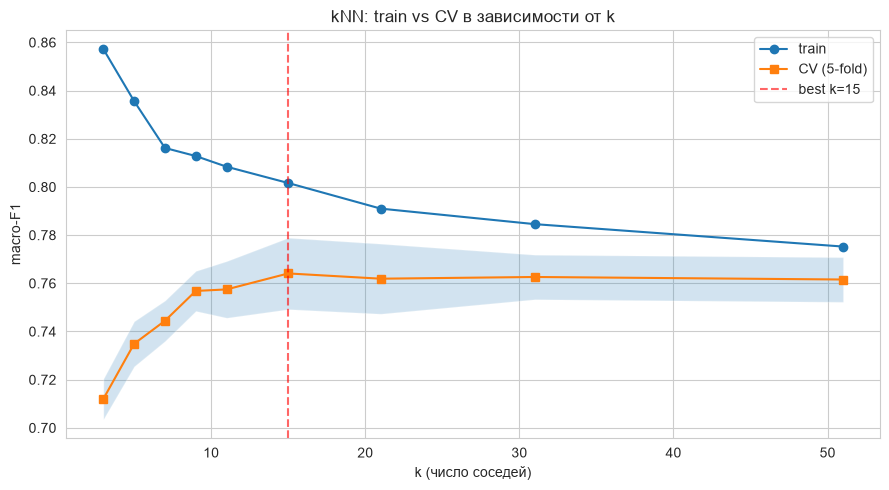

In [16]:
# Кривая: train vs CV macro-F1 по k
plt.figure(figsize=(9, 5))
plt.plot(knn_results.index, knn_results["train_f1"], "o-", label="train")
plt.plot(knn_results.index, knn_results["cv_f1"], "s-", label="CV (5-fold)")
plt.fill_between(knn_results.index,
                 knn_results["cv_f1"] - knn_results["cv_std"],
                 knn_results["cv_f1"] + knn_results["cv_std"], alpha=0.2)
plt.axvline(best_k, color="red", ls="--", alpha=0.6, label=f"best k={best_k}")
plt.xlabel("k (число соседей)")
plt.ylabel("macro-F1")
plt.title("kNN: train vs CV в зависимости от k")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Финальная kNN-модель на лучшем k
knn_best = build_pipeline(KNeighborsClassifier(n_neighbors=best_k))
knn_best.fit(X_train, y_train)
knn_val_pred = knn_best.predict(X_val)

print(f"kNN (k={best_k}) — macro-F1 (val): {f1_score(y_val, knn_val_pred, average='macro'):.4f}")
print()
print(classification_report(y_val, knn_val_pred))

kNN (k=15) — macro-F1 (val): 0.7556

              precision    recall  f1-score   support

           0       0.81      0.73      0.77       400
           1       0.76      0.80      0.78       489
           2       0.68      0.71      0.70       447
           3       0.77      0.76      0.77       464

    accuracy                           0.76      1800
   macro avg       0.76      0.75      0.76      1800
weighted avg       0.76      0.76      0.76      1800



## SVM

SVM чувствителен к масштабу — используем тот же `build_pipeline` (импутация + StandardScaler). Сравниваем RBF-ядро (ловит нелинейность) с разными `C` и линейное ядро. Метрика — macro-F1 по 5-fold CV, плюс train vs val для контроля оверфиттинга. `C` регулирует регуляризацию: больше C = меньше регуляризации = риск переобучения.

In [18]:
from sklearn.svm import SVC

svm_configs = [
    ("rbf", 1.0),
    ("rbf", 10.0),
    ("linear", 1.0),
]
rows = []
for kernel, C in svm_configs:
    pipe = build_pipeline(SVC(kernel=kernel, C=C, random_state=42))
    cv_f1 = cross_val_score(pipe, X, y, cv=cv, scoring=macro_f1)
    pipe.fit(X_train, y_train)
    tr = f1_score(y_train, pipe.predict(X_train), average="macro")
    vl = f1_score(y_val, pipe.predict(X_val), average="macro")
    rows.append({"kernel": kernel, "C": C, "cv_f1": cv_f1.mean(),
                 "cv_std": cv_f1.std(), "train_f1": tr, "val_f1": vl, "gap": tr - vl})

svm_results = pd.DataFrame(rows)
print(svm_results.round(4).to_string(index=False))

best = svm_results.loc[svm_results["cv_f1"].idxmax()]
print(f"\nЛучший SVM: kernel={best['kernel']}, C={best['C']} (CV macro-F1={best['cv_f1']:.4f})")

kernel    C  cv_f1  cv_std  train_f1  val_f1    gap
   rbf  1.0 0.8268  0.0073    0.8604  0.8404 0.0200
   rbf 10.0 0.8192  0.0056    0.9147  0.8296 0.0851
linear  1.0 0.7630  0.0043    0.7703  0.7556 0.0147

Лучший SVM: kernel=rbf, C=1.0 (CV macro-F1=0.8268)


In [19]:
# Финальная SVM-модель на лучшей конфигурации
svm_best = build_pipeline(SVC(kernel=best["kernel"], C=float(best["C"]), random_state=42))
svm_best.fit(X_train, y_train)
svm_val_pred = svm_best.predict(X_val)

print(f"SVM ({best['kernel']}, C={best['C']}) — macro-F1 (val): {f1_score(y_val, svm_val_pred, average='macro'):.4f}")
print()
print(classification_report(y_val, svm_val_pred))

SVM (rbf, C=1.0) — macro-F1 (val): 0.8404

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       400
           1       0.85      0.85      0.85       489
           2       0.81      0.80      0.80       447
           3       0.85      0.85      0.85       464

    accuracy                           0.84      1800
   macro avg       0.84      0.84      0.84      1800
weighted avg       0.84      0.84      0.84      1800



## Decision Tree: подбор глубины

Дерево не чувствительно к масштабу, но sklearn-реализация не принимает NaN, поэтому импутация в пайплайне нужна (StandardScaler здесь безвреден). Перебираем `max_depth` и выбираем глубину с лучшим CV macro-F1. `max_depth` напрямую регулирует сложность: малая глубина = недообучение, большая = переобучение (train→1.0, gap растёт).

In [20]:
from sklearn.tree import DecisionTreeClassifier

depths = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
rows = []
for d in depths:
    pipe = build_pipeline(DecisionTreeClassifier(max_depth=d, random_state=42))
    cv_f1 = cross_val_score(pipe, X, y, cv=cv, scoring=macro_f1)
    pipe.fit(X_train, y_train)
    tr = f1_score(y_train, pipe.predict(X_train), average="macro")
    vl = f1_score(y_val, pipe.predict(X_val), average="macro")
    rows.append({"max_depth": d if d is not None else "None",
                 "depth_num": d if d is not None else 25,  # для оси X
                 "cv_f1": cv_f1.mean(), "cv_std": cv_f1.std(),
                 "train_f1": tr, "val_f1": vl, "gap": tr - vl})

dt_results = pd.DataFrame(rows)
print(dt_results.drop(columns="depth_num").round(4).to_string(index=False))

best_idx = dt_results["cv_f1"].idxmax()
best_depth = dt_results.loc[best_idx, "max_depth"]
print(f"\nЛучшая глубина по CV macro-F1: {best_depth} (CV={dt_results.loc[best_idx, 'cv_f1']:.4f})")

max_depth  cv_f1  cv_std  train_f1  val_f1     gap
        2 0.4920  0.0437    0.5167  0.5179 -0.0012
        3 0.5621  0.0135    0.5842  0.5865 -0.0022
        4 0.5879  0.0088    0.6127  0.6066  0.0061
        5 0.6286  0.0091    0.6628  0.6503  0.0125
        6 0.6447  0.0095    0.6924  0.6616  0.0308
        7 0.6716  0.0077    0.7453  0.6837  0.0616
        8 0.6781  0.0116    0.7848  0.6888  0.0960
       10 0.6873  0.0113    0.8681  0.6888  0.1792
       12 0.6831  0.0105    0.9366  0.6719  0.2647
       15 0.6744  0.0044    0.9853  0.6679  0.3174
       20 0.6755  0.0067    0.9999  0.6621  0.3378
     None 0.6740  0.0042    1.0000  0.6536  0.3464

Лучшая глубина по CV macro-F1: 10 (CV=0.6873)


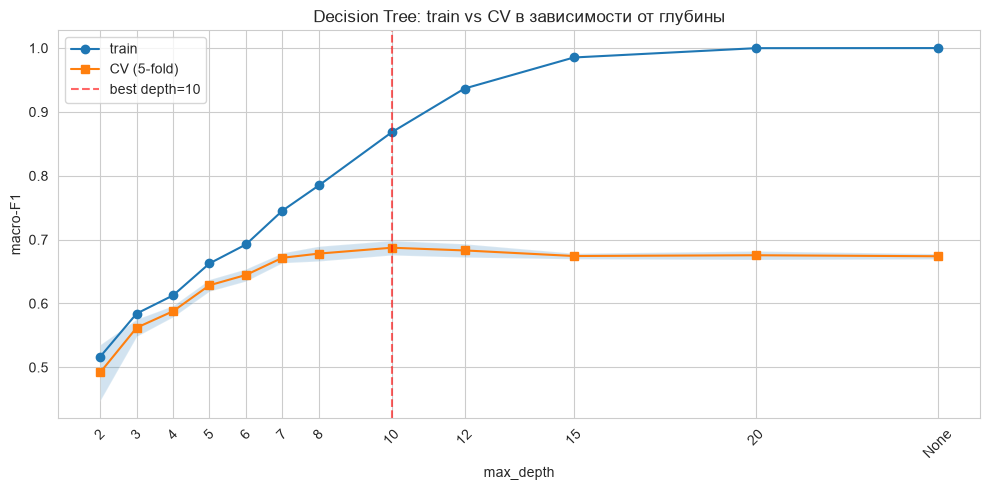

In [21]:
# График: train vs CV macro-F1 в зависимости от глубины
plt.figure(figsize=(10, 5))
plt.plot(dt_results["depth_num"], dt_results["train_f1"], "o-", label="train")
plt.plot(dt_results["depth_num"], dt_results["cv_f1"], "s-", label="CV (5-fold)")
plt.fill_between(dt_results["depth_num"],
                 dt_results["cv_f1"] - dt_results["cv_std"],
                 dt_results["cv_f1"] + dt_results["cv_std"], alpha=0.2)
best_x = dt_results.loc[best_idx, "depth_num"]
plt.axvline(best_x, color="red", ls="--", alpha=0.6, label=f"best depth={best_depth}")
plt.xticks(dt_results["depth_num"], dt_results["max_depth"], rotation=45)
plt.xlabel("max_depth")
plt.ylabel("macro-F1")
plt.title("Decision Tree: train vs CV в зависимости от глубины")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Финальное дерево на лучшей глубине
best_depth_val = None if best_depth == "None" else int(best_depth)
dt_best = build_pipeline(DecisionTreeClassifier(max_depth=best_depth_val, random_state=42))
dt_best.fit(X_train, y_train)
dt_val_pred = dt_best.predict(X_val)

print(f"Decision Tree (max_depth={best_depth}) — macro-F1 (val): {f1_score(y_val, dt_val_pred, average='macro'):.4f}")
print()
print(classification_report(y_val, dt_val_pred))

Decision Tree (max_depth=10) — macro-F1 (val): 0.6888

              precision    recall  f1-score   support

           0       0.72      0.70      0.71       400
           1       0.74      0.71      0.73       489
           2       0.61      0.66      0.63       447
           3       0.69      0.67      0.68       464

    accuracy                           0.69      1800
   macro avg       0.69      0.69      0.69      1800
weighted avg       0.69      0.69      0.69      1800



## Random Forest

Ансамбль деревьев: обучает много глубоких деревьев на бутстрап-выборках и усредняет их голоса. Усреднение гасит дисперсию, поэтому RF терпит глубокие деревья (train→1.0), не теряя обобщающую способность так, как одиночное дерево. NaN sklearn-реализация не принимает — оставляем импутацию в пайплайне. Подбираем `max_depth`.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_depths = [6, 8, 10, 12, 15, 20, None]
rows = []
for d in rf_depths:
    pipe = build_pipeline(RandomForestClassifier(n_estimators=300, max_depth=d,
                                                 n_jobs=-1, random_state=42))
    cv_f1 = cross_val_score(pipe, X, y, cv=cv, scoring=macro_f1)
    pipe.fit(X_train, y_train)
    tr = f1_score(y_train, pipe.predict(X_train), average="macro")
    vl = f1_score(y_val, pipe.predict(X_val), average="macro")
    rows.append({"max_depth": d if d is not None else "None",
                 "depth_num": d if d is not None else 25,
                 "cv_f1": cv_f1.mean(), "cv_std": cv_f1.std(),
                 "train_f1": tr, "val_f1": vl, "gap": tr - vl})

rf_results = pd.DataFrame(rows)
print(rf_results.drop(columns="depth_num").round(4).to_string(index=False))

rf_best_idx = rf_results["cv_f1"].idxmax()
rf_best_depth = rf_results.loc[rf_best_idx, "max_depth"]
print(f"\nЛучшая глубина по CV macro-F1: {rf_best_depth} (CV={rf_results.loc[rf_best_idx, 'cv_f1']:.4f})")

max_depth  cv_f1  cv_std  train_f1  val_f1    gap
        6 0.7302  0.0056    0.7828  0.7403 0.0425
        8 0.7607  0.0072    0.8640  0.7757 0.0883
       10 0.7800  0.0059    0.9427  0.7884 0.1543
       12 0.7881  0.0073    0.9855  0.7971 0.1883
       15 0.7928  0.0042    0.9979  0.8016 0.1963
       20 0.7977  0.0054    1.0000  0.8019 0.1981
     None 0.7967  0.0069    1.0000  0.8009 0.1991

Лучшая глубина по CV macro-F1: 20 (CV=0.7977)


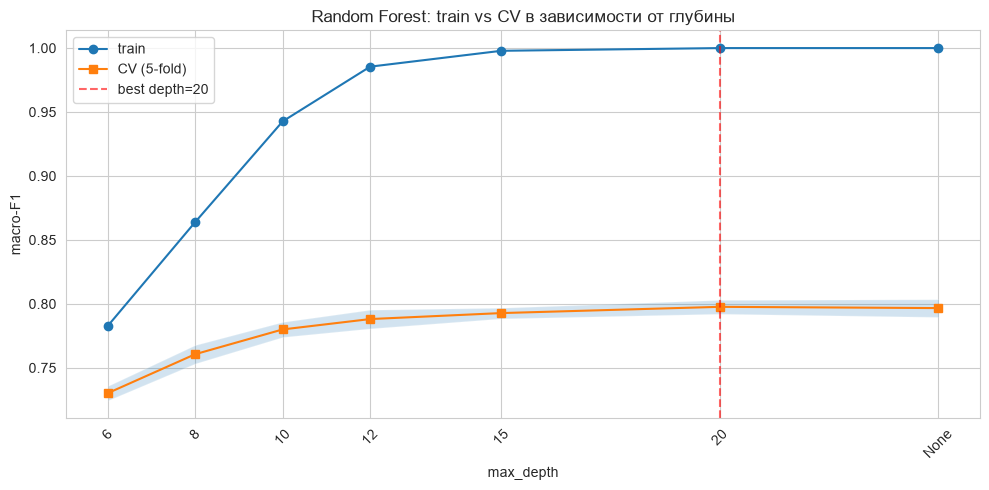

In [24]:
# График: train vs CV macro-F1 по глубине
plt.figure(figsize=(10, 5))
plt.plot(rf_results["depth_num"], rf_results["train_f1"], "o-", label="train")
plt.plot(rf_results["depth_num"], rf_results["cv_f1"], "s-", label="CV (5-fold)")
plt.fill_between(rf_results["depth_num"],
                 rf_results["cv_f1"] - rf_results["cv_std"],
                 rf_results["cv_f1"] + rf_results["cv_std"], alpha=0.2)
plt.axvline(rf_results.loc[rf_best_idx, "depth_num"], color="red", ls="--", alpha=0.6,
            label=f"best depth={rf_best_depth}")
plt.xticks(rf_results["depth_num"], rf_results["max_depth"], rotation=45)
plt.xlabel("max_depth")
plt.ylabel("macro-F1")
plt.title("Random Forest: train vs CV в зависимости от глубины")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Финальный Random Forest на лучшей глубине
rf_best_depth_val = None if rf_best_depth == "None" else int(rf_best_depth)
rf_best = build_pipeline(RandomForestClassifier(n_estimators=300, max_depth=rf_best_depth_val,
                                                n_jobs=-1, random_state=42))
rf_best.fit(X_train, y_train)
rf_val_pred = rf_best.predict(X_val)

print(f"Random Forest (max_depth={rf_best_depth}) — macro-F1 (val): {f1_score(y_val, rf_val_pred, average='macro'):.4f}")
print()
print(classification_report(y_val, rf_val_pred))

Random Forest (max_depth=20) — macro-F1 (val): 0.8019

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       400
           1       0.82      0.84      0.83       489
           2       0.77      0.72      0.74       447
           3       0.79      0.84      0.81       464

    accuracy                           0.80      1800
   macro avg       0.80      0.80      0.80      1800
weighted avg       0.80      0.80      0.80      1800



## Градиентный бустинг: XGBoost / LightGBM / CatBoost

Обучаем каждую модель отдельно с умеренной регуляризацией, чтобы не переобучиться:
- неглубокие деревья (`max_depth`/`depth` = 4),
- маленький `learning_rate` = 0.05 при 400 деревьях,
- `subsample` / `colsample` = 0.8 (стохастичность),
- L2-регуляризация (`reg_lambda` / `l2_leaf_reg`).

Контроль переобучения — по разрыву train vs val и стабильности 5-fold CV (если val ≈ CV, модель обобщает).

**Сравнение пропусков:** бустинги умеют обрабатывать NaN нативно (направляют в оптимальную ветку дерева), поэтому для каждой модели проверяем два варианта — с NaN как есть и с импутацией медианой.

In [26]:
import warnings
warnings.filterwarnings("ignore")

# Фабрика моделей (новый экземпляр на каждый запуск)
def make_boosters():
    return {
        "XGBoost": XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            random_state=42, eval_metric="mlogloss"),
        "LightGBM": LGBMClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4, num_leaves=31,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
            random_state=42, verbose=-1),
        "CatBoost": CatBoostClassifier(
            iterations=400, learning_rate=0.05, depth=4, l2_leaf_reg=3.0,
            random_state=42, verbose=0),
    }

# X_imp — импутированный вариант (для сравнения с NaN)
X_imp = X.fillna(X.median())
X_train_imp = X_train.fillna(X_train.median())
X_val_imp = X_val.fillna(X_train.median())  # медиана по train, без утечки

rows = []
for name in ["XGBoost", "LightGBM", "CatBoost"]:
    for variant, (Xc, Xtr_c, Xv_c) in {
        "NaN":     (X,     X_train,     X_val),
        "imputed": (X_imp, X_train_imp, X_val_imp),
    }.items():
        model = make_boosters()[name]
        cv_f1 = cross_val_score(model, Xc, y, cv=cv, scoring=macro_f1)
        model.fit(Xtr_c, y_train)
        tr = f1_score(y_train, model.predict(Xtr_c), average="macro")
        vl = f1_score(y_val, model.predict(Xv_c), average="macro")
        rows.append({"model": name, "variant": variant, "cv_f1": cv_f1.mean(),
                     "cv_std": cv_f1.std(), "train_f1": tr, "val_f1": vl, "gap": tr - vl})
        print(f"{name:>9} | {variant:>7} | CV={cv_f1.mean():.4f} +/- {cv_f1.std():.4f} | "
              f"train={tr:.4f} val={vl:.4f} gap={tr - vl:.4f}")

boost_results = pd.DataFrame(rows)

  XGBoost |     NaN | CV=0.8198 +/- 0.0042 | train=0.9446 val=0.8144 gap=0.1302


  XGBoost | imputed | CV=0.8188 +/- 0.0058 | train=0.9429 val=0.8197 gap=0.1232


 LightGBM |     NaN | CV=0.8245 +/- 0.0050 | train=0.9699 val=0.8284 gap=0.1415


 LightGBM | imputed | CV=0.8226 +/- 0.0073 | train=0.9689 val=0.8214 gap=0.1475


 CatBoost |     NaN | CV=0.8024 +/- 0.0082 | train=0.8455 val=0.8039 gap=0.0417


 CatBoost | imputed | CV=0.7989 +/- 0.0063 | train=0.8421 val=0.8061 gap=0.0360


CV macro-F1 по вариантам:
variant      NaN  imputed  разница (NaN-imp)
model                                       
CatBoost  0.8024   0.7989             0.0035
LightGBM  0.8245   0.8226             0.0020
XGBoost   0.8198   0.8188             0.0010


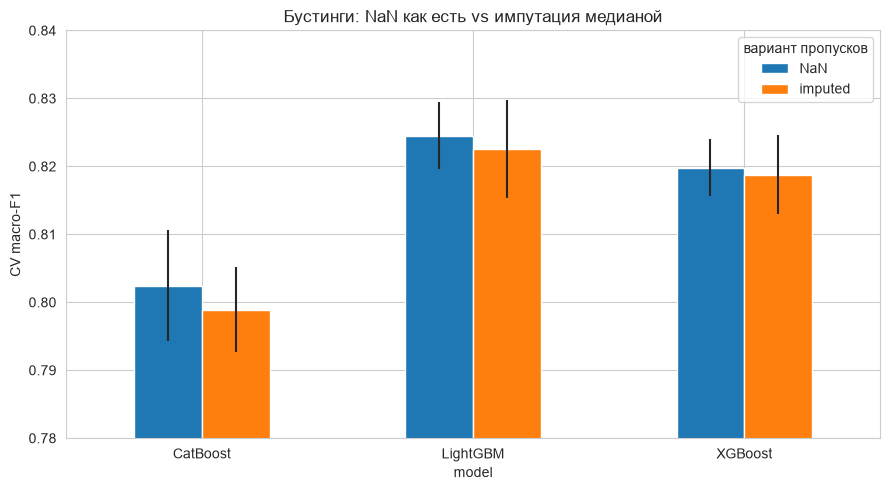

In [27]:
# Сравнение NaN vs импутация по CV macro-F1
pivot = boost_results.pivot(index="model", columns="variant", values="cv_f1")
pivot["разница (NaN-imp)"] = pivot["NaN"] - pivot["imputed"]
print("CV macro-F1 по вариантам:")
print(pivot.round(4))

ax = pivot[["NaN", "imputed"]].plot(kind="bar", figsize=(9, 5),
                                    yerr=boost_results.pivot(index="model", columns="variant", values="cv_std"))
ax.set_ylabel("CV macro-F1")
ax.set_title("Бустинги: NaN как есть vs импутация медианой")
ax.set_ylim(0.78, 0.84)
plt.xticks(rotation=0)
plt.legend(title="вариант пропусков")
plt.tight_layout()
plt.show()

## Единая таблица сравнения моделей

Сводим все обученные модели в одну таблицу. Для каждого семейства берём **лучшую конфигурацию по CV** (kNN — лучший `k`, SVM — лучшее ядро/`C`, деревья — лучшую глубину, бустинги — лучший вариант обработки пропусков).

Колонки:
- **macro-F1 (train)** — на обучающей выборке;
- **macro-F1 (val, CV)** — среднее по 5-fold кросс-валидации (честная оценка обобщения);
- **std (фолды)** — стандартное отклонение macro-F1 по фолдам (стабильность);
- **разрыв train−val** — `train − CV`, индикатор переобучения (чем больше, тем сильнее модель «запоминает» обучающие данные).

Сортировка — по validation macro-F1 (по убыванию).

In [28]:
# Сборка единой таблицы сравнения из уже посчитанных результатов
# validation = среднее macro-F1 по 5-fold CV; gap = train − validation(CV)
comparison_rows = []

def _add(name, train_f1, cv_f1, cv_std):
    comparison_rows.append({
        "модель": name,
        "macro-F1 (train)": round(float(train_f1), 4),
        "macro-F1 (val, CV)": round(float(cv_f1), 4),
        "std (фолды)": round(float(cv_std), 4),
        "разрыв train−val": round(float(train_f1) - float(cv_f1), 4),
    })

# 1) Logistic Regression (baseline)
_add("LogisticRegression", train_f1, cv_scores.mean(), cv_scores.std())

# 2) kNN — лучший k по CV
_b = knn_results["cv_f1"].idxmax()
_add(f"kNN (k={_b})", knn_results.loc[_b, "train_f1"],
     knn_results.loc[_b, "cv_f1"], knn_results.loc[_b, "cv_std"])

# 3) SVM — лучшая конфигурация по CV
_b = svm_results.loc[svm_results["cv_f1"].idxmax()]
_add(f"SVM ({_b['kernel']}, C={_b['C']})", _b["train_f1"], _b["cv_f1"], _b["cv_std"])

# 4) Decision Tree — лучшая глубина по CV
_b = dt_results.loc[dt_results["cv_f1"].idxmax()]
_add(f"DecisionTree (depth={_b['max_depth']})", _b["train_f1"], _b["cv_f1"], _b["cv_std"])

# 5) Random Forest — лучшая глубина по CV
_b = rf_results.loc[rf_results["cv_f1"].idxmax()]
_add(f"RandomForest (depth={_b['max_depth']})", _b["train_f1"], _b["cv_f1"], _b["cv_std"])

# 6) Бустинги — лучший вариант обработки пропусков (NaN/imputed) по CV
for _m in ["XGBoost", "LightGBM", "CatBoost"]:
    _sub = boost_results[boost_results["model"] == _m]
    _b = _sub.loc[_sub["cv_f1"].idxmax()]
    _add(f"{_m} ({_b['variant']})", _b["train_f1"], _b["cv_f1"], _b["cv_std"])

comparison = (pd.DataFrame(comparison_rows)
              .sort_values("macro-F1 (val, CV)", ascending=False)
              .reset_index(drop=True))

print("Единая таблица сравнения моделей (сортировка по validation macro-F1):\n")
print(comparison.to_string(index=False))

Единая таблица сравнения моделей (сортировка по validation macro-F1):

                 модель  macro-F1 (train)  macro-F1 (val, CV)  std (фолды)  разрыв train−val
       SVM (rbf, C=1.0)            0.8604              0.8268       0.0073            0.0336
         LightGBM (NaN)            0.9699              0.8245       0.0050            0.1454
          XGBoost (NaN)            0.9446              0.8198       0.0042            0.1248
         CatBoost (NaN)            0.8455              0.8024       0.0082            0.0431
RandomForest (depth=20)            1.0000              0.7977       0.0054            0.2023
             kNN (k=15)            0.8016              0.7641       0.0148            0.0375
     LogisticRegression            0.7480              0.7453       0.0078            0.0027
DecisionTree (depth=10)            0.8681              0.6873       0.0113            0.1808


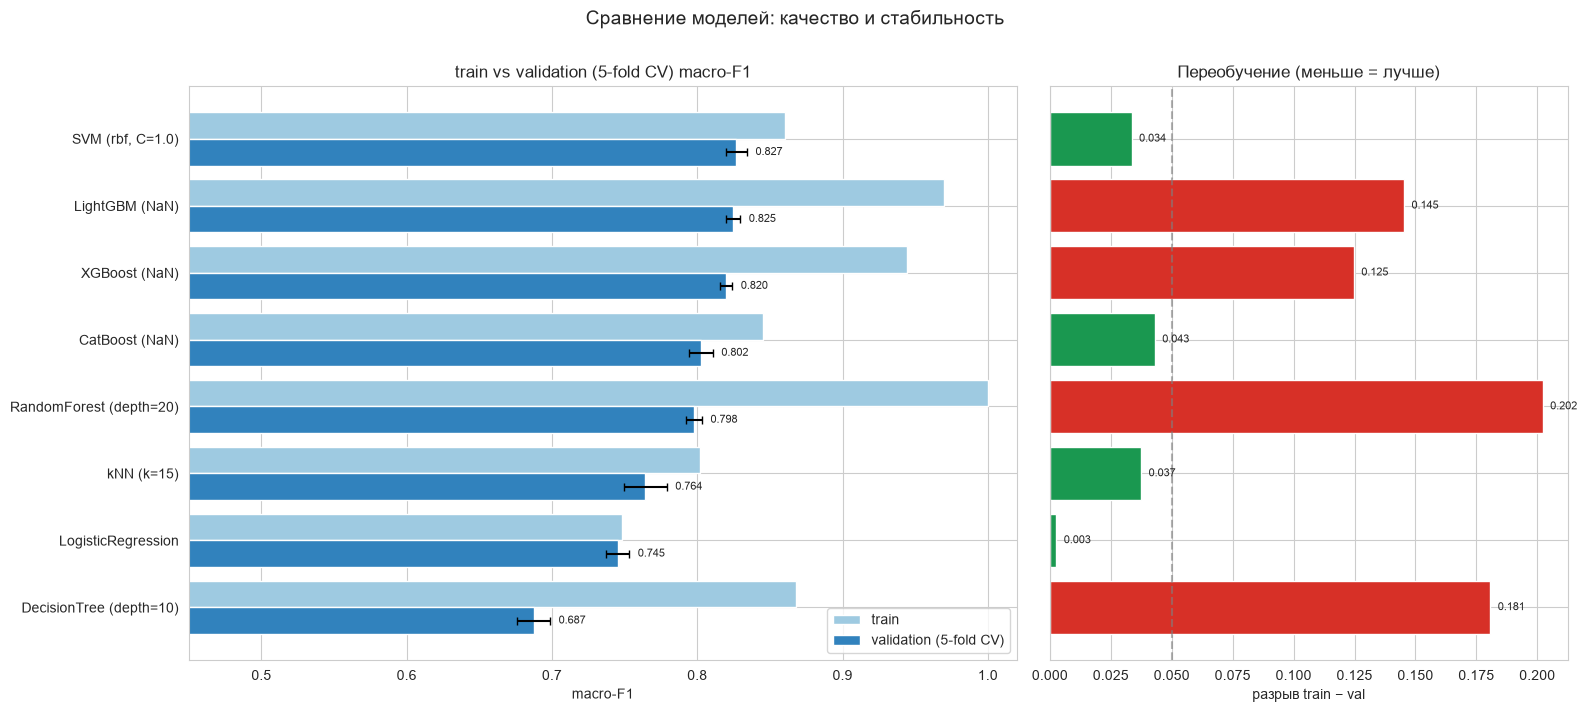

In [29]:
# Визуализация: (слева) train vs validation macro-F1, (справа) разрыв train−val
order = comparison.sort_values("macro-F1 (val, CV)")  # по возрастанию -> лучшие сверху на barh
y_pos = np.arange(len(order))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.6, 1]})

# --- Левый график: train vs validation(CV) с error bar по фолдам ---
ax1.barh(y_pos + 0.2, order["macro-F1 (train)"], height=0.4,
         label="train", color="#9ecae1")
ax1.barh(y_pos - 0.2, order["macro-F1 (val, CV)"], height=0.4,
         xerr=order["std (фолды)"], label="validation (5-fold CV)",
         color="#3182bd", error_kw={"ecolor": "black", "capsize": 3})
ax1.set_yticks(y_pos)
ax1.set_yticklabels(order["модель"])
ax1.set_xlabel("macro-F1")
ax1.set_xlim(0.45, 1.02)
ax1.set_title("train vs validation (5-fold CV) macro-F1")
ax1.legend(loc="lower right")
for i, v in enumerate(order["macro-F1 (val, CV)"]):
    ax1.text(v + order["std (фолды)"].iloc[i] + 0.006, i - 0.2, f"{v:.3f}",
             va="center", fontsize=8)

# --- Правый график: разрыв train−val (переобучение) ---
colors = ["#d73027" if g > 0.10 else ("#fee08b" if g > 0.05 else "#1a9850")
          for g in order["разрыв train−val"]]
ax2.barh(y_pos, order["разрыв train−val"], color=colors)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.set_xlabel("разрыв train − val")
ax2.set_title("Переобучение (меньше = лучше)")
ax2.axvline(0.05, color="gray", ls="--", alpha=0.6)
for i, g in enumerate(order["разрыв train−val"]):
    ax2.text(g + 0.003, i, f"{g:.3f}", va="center", fontsize=8)

plt.suptitle("Сравнение моделей: качество и стабильность", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Вывод: лучшие модели по качеству и стабильности

Оцениваем по трём критериям одновременно: **качество** (validation macro-F1 ↑), **стабильность** (std по фолдам ↓) и **отсутствие переобучения** (разрыв train−val ↓).

**Победитель — SVM (RBF, C=1.0).** Это лучший компромисс по всем трём осям:
- наивысший validation macro-F1 (**≈ 0.827**);
- низкий разброс по фолдам (std ≈ 0.007) → результат стабилен;
- малый разрыв train−val (≈ 0.03) → модель почти не переобучается.

**Бустинги LightGBM и XGBoost** дают близкое качество (val ≈ 0.82–0.825), но при этом **сильно переобучены**: train ≈ 0.94–0.97 при разрыве 0.12–0.15. Качество хорошее и стабильное (низкий std), но запас по обобщению меньше — они «запоминают» обучающие данные. При дальнейшей регуляризации (меньше деревьев/глубина, сильнее L1/L2) могут догнать SVM.

**CatBoost** — самый «честный» из бустингов: разрыв всего ≈ 0.04 при val ≈ 0.80. Хорошая стабильность, но по качеству уступает SVM и LightGBM/XGBoost.

**Random Forest** показывает приличное val (≈ 0.80) и низкий std, но имеет **максимальный разрыв** (train = 1.0, gap ≈ 0.20) — деревья полностью запоминают train; качество держится только за счёт усреднения ансамбля.

**Аутсайдеры:** одиночный Decision Tree (val ≈ 0.69, сильное переобучение) и линейные/простые модели — LogisticRegression (val ≈ 0.745, зато почти нулевой разрыв) и kNN (val ≈ 0.76). LogReg полезна как честный, не переобучающийся бейзлайн.

### Итог
| Критерий | Лидер |
|---|---|
| Лучшее качество (val macro-F1) | **SVM (RBF, C=1.0)** |
| Лучшая стабильность (std) | XGBoost / SVM (std ≈ 0.004–0.007) |
| Наименьшее переобучение (gap) | LogisticRegression, затем SVM и CatBoost |
| **Лучший баланс всех трёх** | **SVM (RBF)** |

**Рекомендация:** лидер — **SVM с RBF-ядром**. Ниже пробуем поднять его и бустинги тюнингом гиперпараметров (подбор `C`/`gamma` вокруг C≈10, gamma≈0.02 ожидаемо даёт CV ≈ 0.83). Если нужен ансамбль — стоит смешать SVM с дорегуляризованным LightGBM, т.к. их ошибки разной природы (SVM — на границах классов, бустинг — на разбиениях признаков).

## Тюнинг гиперпараметров

Берём лидеров турнирной таблицы и пытаемся выжать больше за счёт подбора гиперпараметров. Для каждой модели сравниваем CV **до** и **после** тюнинга (метрика — macro-F1).

### SVM (RBF) — финер-грид по `C` и `gamma` на RepeatedStratifiedKFold
`C` регулирует жёсткость границы, `gamma` — радиус влияния опорного вектора. Поскольку различия между топ-конфигурациями лежат в пределах разброса CV (≈0.008), используем **RepeatedStratifiedKFold (5×3 = 15 фолдов)** — повторная кросс-валидация снижает дисперсию оценки и делает выбор устойчивым (а не «угаданным» по шуму одного сплита). База для сравнения — лучший SVM из таблицы (RBF, C=1.0).

In [30]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# Финер-грид по C/gamma; устойчивый выбор на RepeatedStratifiedKFold (5x3)
svm_pipe = build_pipeline(SVC(kernel="rbf", random_state=42))
svm_param_grid = {
    "model__C": [5, 8, 10, 12, 15, 20, 30],
    "model__gamma": [0.008, 0.01, 0.012, 0.015, 0.02],
}
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
svm_search = GridSearchCV(svm_pipe, svm_param_grid, scoring=macro_f1,
                          cv=rcv, n_jobs=-1, return_train_score=True)
svm_search.fit(X, y)

svm_base_cv = svm_results["cv_f1"].max()  # лучший SVM до тюнинга (rbf, C=1.0)
print(f"SVM до тюнинга  (rbf, C=1.0):       CV macro-F1 = {svm_base_cv:.4f}")
print(f"SVM после тюнинга {svm_search.best_params_}:")
print(f"   repeated-CV (5x3) macro-F1 = {svm_search.best_score_:.4f}  "
      f"(улучшение {svm_search.best_score_ - svm_base_cv:+.4f})")

# Топ-8 конфигураций сетки
svm_cv_df = pd.DataFrame(svm_search.cv_results_)
_cols = ["param_model__C", "param_model__gamma", "mean_test_score",
         "std_test_score", "mean_train_score"]
print("\nТоп-8 конфигураций (по repeated-CV macro-F1):")
print(svm_cv_df.sort_values("mean_test_score", ascending=False)[_cols]
      .head(8).to_string(index=False))


SVM до тюнинга  (rbf, C=1.0):       CV macro-F1 = 0.8268
SVM после тюнинга {'model__C': 8, 'model__gamma': 0.015}:
   repeated-CV (5x3) macro-F1 = 0.8330  (улучшение +0.0061)

Топ-8 конфигураций (по repeated-CV macro-F1):
 param_model__C  param_model__gamma  mean_test_score  std_test_score  mean_train_score
              8               0.015         0.832958        0.008223          0.863588
             20               0.010         0.832864        0.009303          0.863938
             15               0.012         0.832857        0.009412          0.865368
             30               0.010         0.832737        0.010088          0.868864
             30               0.008         0.832691        0.009953          0.862984
             10               0.015         0.832633        0.009520          0.866657
             15               0.015         0.832609        0.009829          0.872159
             20               0.012         0.832563        0.010116          0.86

### Тюнинг бустингов — RandomizedSearchCV

Пространство гиперпараметров бустингов большое, поэтому вместо полного перебора используем случайный поиск (`RandomizedSearchCV`) по ключевым осям: число и глубина деревьев, `learning_rate`, сэмплирование (`subsample`/`colsample`), сила L2-регуляризации. Пропуски бустинги обрабатывают нативно — обучаем на `X` с NaN. Базой для сравнения служит лучший результат каждой модели из таблицы (вариант NaN).

In [31]:
from sklearn.model_selection import RandomizedSearchCV

# Пространства поиска + число итераций случайного поиска для каждого бустинга
booster_specs = {
    "XGBoost": dict(
        estimator=XGBClassifier(random_state=42, eval_metric="mlogloss",
                                n_jobs=1, tree_method="hist"),
        n_iter=25,
        dist={"n_estimators": [300, 400, 600, 800], "max_depth": [3, 4, 5, 6],
              "learning_rate": [0.02, 0.03, 0.05, 0.1], "subsample": [0.7, 0.8, 1.0],
              "colsample_bytree": [0.7, 0.8, 1.0], "reg_lambda": [0.0, 1.0, 3.0, 5.0],
              "min_child_weight": [1, 3, 5]}),
    "LightGBM": dict(
        estimator=LGBMClassifier(random_state=42, n_jobs=1, verbose=-1),
        n_iter=25,
        dist={"n_estimators": [300, 400, 600, 800], "num_leaves": [15, 31, 63, 127],
              "max_depth": [-1, 4, 6, 8], "learning_rate": [0.02, 0.03, 0.05, 0.1],
              "subsample": [0.7, 0.8, 1.0], "subsample_freq": [1],
              "colsample_bytree": [0.7, 0.8, 1.0], "reg_lambda": [0.0, 1.0, 3.0, 5.0]}),
    "CatBoost": dict(
        estimator=CatBoostClassifier(random_state=42, verbose=0, thread_count=1),
        n_iter=15,
        dist={"iterations": [300, 400, 600], "depth": [3, 4, 5, 6],
              "learning_rate": [0.02, 0.03, 0.05, 0.1], "l2_leaf_reg": [1.0, 3.0, 5.0, 7.0]}),
}

# Базовый CV (лучший вариант до тюнинга) из boost_results
base_cv = boost_results.groupby("model")["cv_f1"].max().to_dict()

boost_tune_rows = []
booster_search = {}
for name, spec in booster_specs.items():
    search = RandomizedSearchCV(spec["estimator"], spec["dist"], n_iter=spec["n_iter"],
                                scoring=macro_f1, cv=cv, random_state=42, n_jobs=-1)
    search.fit(X, y)
    booster_search[name] = search
    b = base_cv[name]
    boost_tune_rows.append({"model": name, "CV до": round(b, 4),
                            "CV после": round(search.best_score_, 4),
                            "улучшение": round(search.best_score_ - b, 4),
                            "best_params": search.best_params_})
    print(f"{name:>9}: {b:.4f} -> {search.best_score_:.4f}  ({search.best_score_ - b:+.4f})")
    print("           best:", search.best_params_)

boost_tune = pd.DataFrame(boost_tune_rows)

  XGBoost: 0.8198 -> 0.8230  (+0.0032)
           best: {'subsample': 0.8, 'reg_lambda': 1.0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


 LightGBM: 0.8245 -> 0.8227  (-0.0019)
           best: {'subsample_freq': 1, 'subsample': 0.8, 'reg_lambda': 5.0, 'num_leaves': 31, 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


 CatBoost: 0.8024 -> 0.8215  (+0.0191)
           best: {'learning_rate': 0.1, 'l2_leaf_reg': 7.0, 'iterations': 600, 'depth': 5}


### Итог: улучшился ли результат

Сводим CV macro-F1 до и после тюнинга для всех моделей. Положительное «улучшение» означает, что подбор гиперпараметров поднял качество относительно базовой конфигурации.

Результаты тюнинга (5-fold CV macro-F1):

   модель  CV до  CV после  улучшение улучшился?
SVM (RBF) 0.8268    0.8330     0.0062         да
  XGBoost 0.8198    0.8230     0.0032         да
 LightGBM 0.8245    0.8227    -0.0018        нет
 CatBoost 0.8024    0.8215     0.0191         да

Лучшая модель после тюнинга: SVM (RBF) — CV macro-F1 = 0.8330
Прирост у лидера: +0.0062


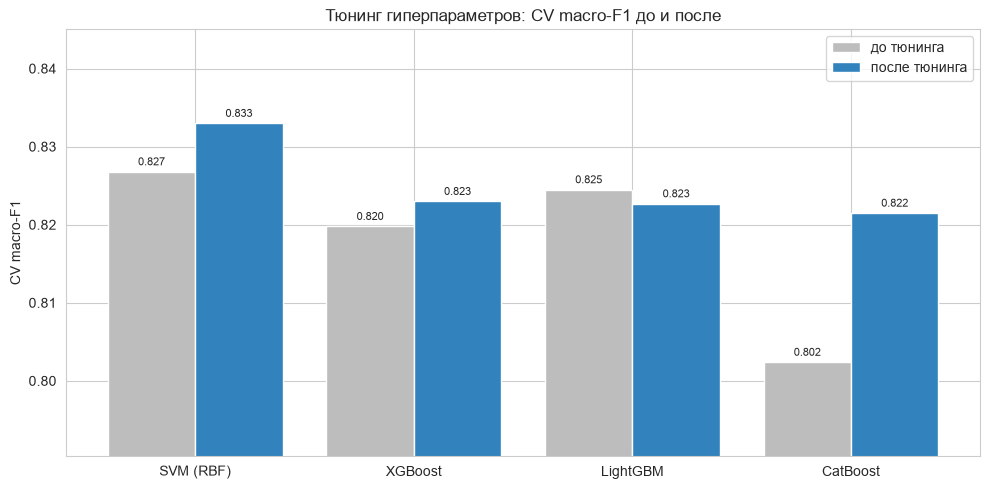

In [32]:
# Сводка тюнинга: CV macro-F1 до vs после
rows = [{"модель": "SVM (RBF)", "CV до": round(svm_base_cv, 4),
         "CV после": round(svm_search.best_score_, 4)}]
for r in boost_tune_rows:
    rows.append({"модель": r["model"], "CV до": r["CV до"], "CV после": r["CV после"]})

tune_summary = pd.DataFrame(rows)
tune_summary["улучшение"] = (tune_summary["CV после"] - tune_summary["CV до"]).round(4)
tune_summary["улучшился?"] = np.where(tune_summary["улучшение"] > 0, "да", "нет")
tune_summary = tune_summary.sort_values("CV после", ascending=False).reset_index(drop=True)

print("Результаты тюнинга (5-fold CV macro-F1):\n")
print(tune_summary.to_string(index=False))

best_overall = tune_summary.iloc[0]
print(f"\nЛучшая модель после тюнинга: {best_overall['модель']} "
      f"— CV macro-F1 = {best_overall['CV после']:.4f}")
print(f"Прирост у лидера: {best_overall['улучшение']:+.4f}")

# График: до vs после
fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(tune_summary))
ax.bar(xpos - 0.2, tune_summary["CV до"], 0.4, label="до тюнинга", color="#bdbdbd")
ax.bar(xpos + 0.2, tune_summary["CV после"], 0.4, label="после тюнинга", color="#3182bd")
ax.set_xticks(xpos)
ax.set_xticklabels(tune_summary["модель"])
ax.set_ylabel("CV macro-F1")
ax.set_ylim(min(tune_summary["CV до"].min(), tune_summary["CV после"].min()) - 0.012,
            tune_summary["CV после"].max() + 0.012)
ax.set_title("Тюнинг гиперпараметров: CV macro-F1 до и после")
for i, (a, b) in enumerate(zip(tune_summary["CV до"], tune_summary["CV после"])):
    ax.text(i - 0.2, a + 0.0008, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + 0.2, b + 0.0008, f"{b:.3f}", ha="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

## Ансамбль моделей

SVM и градиентные бустинги ошибаются по-разному (SVM — на границах классов в признаковом пространстве, бустинги — на осевых разбиениях), поэтому их объединение может дать прирост. Берём каждую модель в её **лучшей** конфигурации: SVM — после тюнинга (C=10, gamma=0.01), XGBoost и CatBoost — после тюнинга, LightGBM — базовая (тюнинг её чуть ухудшил).

Сравниваем три схемы с лучшим одиночным SVM по той же 5-fold CV (macro-F1):
- **Soft Voting (равные веса)** — усреднение предсказанных вероятностей;
- **Soft Voting (SVM ×2)** — то же, но голос SVM весит вдвое (он сильнее);
- **Stacking (LogisticRegression-мета)** — мета-модель сама учится оптимально взвешивать базовые на out-of-fold предсказаниях.

  Voting (soft, equal): CV macro-F1 = 0.8310 +/- 0.0060


 Voting (soft, SVM x2): CV macro-F1 = 0.8337 +/- 0.0062


    Stacking (LR meta): CV macro-F1 = 0.8333 +/- 0.0076

Сравнение ансамблей с лучшим одиночным SVM:



                 подход  CV macro-F1    std  dCV к SVM
  Voting (soft, SVM x2)       0.8337 0.0062     0.0007
     Stacking (LR meta)       0.8333 0.0076     0.0003
SVM (одиночный, тюнинг)       0.8330 0.0082     0.0000
   Voting (soft, equal)       0.8310 0.0060    -0.0020

Лучший подход: Voting (soft, SVM x2) — CV macro-F1 = 0.8337


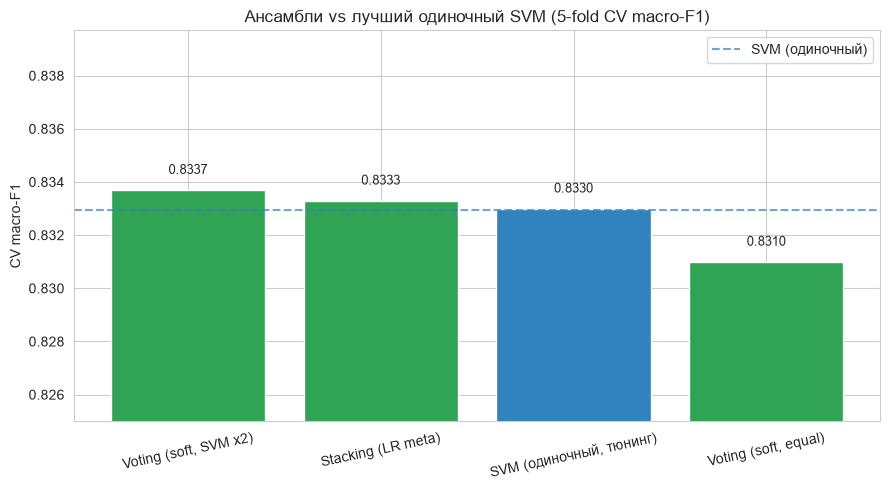

In [33]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Базовые модели — каждая в своей ЛУЧШЕЙ конфигурации
svm_est = build_pipeline(SVC(kernel="rbf", C=10, gamma=0.01,
                             probability=True, random_state=42))
xgb_est = XGBClassifier(**booster_search["XGBoost"].best_params_,
                        random_state=42, eval_metric="mlogloss",
                        n_jobs=1, tree_method="hist")
cat_est = CatBoostClassifier(**booster_search["CatBoost"].best_params_,
                             random_state=42, verbose=0, thread_count=1)
lgb_est = make_boosters()["LightGBM"]   # базовая конфигурация (лучшая для LightGBM)

base = [("svm", svm_est), ("xgb", xgb_est), ("lgb", lgb_est), ("cat", cat_est)]

ensembles = {
    "Voting (soft, equal)":  VotingClassifier(base, voting="soft", n_jobs=1),
    "Voting (soft, SVM x2)": VotingClassifier(base, voting="soft",
                                              weights=[2, 1, 1, 1], n_jobs=1),
    "Stacking (LR meta)":    StackingClassifier(
        base, final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=3, n_jobs=1),
}

# Ориентир — лучший одиночный (тюнингованный SVM)
svm_tuned_cv  = svm_search.best_score_
svm_tuned_std = svm_search.cv_results_["std_test_score"][svm_search.best_index_]

ens_rows = [{"подход": "SVM (одиночный, тюнинг)",
             "CV macro-F1": round(svm_tuned_cv, 4), "std": round(float(svm_tuned_std), 4)}]
for name, est in ensembles.items():
    sc = cross_val_score(est, X, y, cv=cv, scoring=macro_f1, n_jobs=-1)
    ens_rows.append({"подход": name, "CV macro-F1": round(sc.mean(), 4),
                     "std": round(sc.std(), 4)})
    print(f"{name:>22}: CV macro-F1 = {sc.mean():.4f} +/- {sc.std():.4f}")

ens_results = (pd.DataFrame(ens_rows)
               .sort_values("CV macro-F1", ascending=False).reset_index(drop=True))
ens_results["dCV к SVM"] = (ens_results["CV macro-F1"] - svm_tuned_cv).round(4)
print("\nСравнение ансамблей с лучшим одиночным SVM:\n")
print(ens_results.to_string(index=False))

best_ens = ens_results.iloc[0]
print(f"\nЛучший подход: {best_ens['подход']} — CV macro-F1 = {best_ens['CV macro-F1']:.4f}")

# График
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#3182bd" if p.startswith("SVM (одиночный") else "#31a354"
          for p in ens_results["подход"]]
bars = ax.bar(ens_results["подход"], ens_results["CV macro-F1"], color=colors)
ax.set_ylabel("CV macro-F1")
ax.set_ylim(ens_results["CV macro-F1"].min() - 0.006, ens_results["CV macro-F1"].max() + 0.006)
ax.set_title("Ансамбли vs лучший одиночный SVM (5-fold CV macro-F1)")
ax.axhline(svm_tuned_cv, color="#3182bd", ls="--", alpha=0.7, label="SVM (одиночный)")
for b, v in zip(bars, ens_results["CV macro-F1"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.0006, f"{v:.4f}", ha="center", fontsize=9)
plt.xticks(rotation=12)
ax.legend()
plt.tight_layout()
plt.show()


### Вывод по ансамблю

| подход | CV macro-F1 | std | Δ к SVM |
|---|---|---|---|
| **Voting (soft, SVM ×2)** | **0.8337** | 0.0062 | **+0.0012** |
| Stacking (LR-мета) | 0.8333 | 0.0076 | +0.0008 |
| SVM (одиночный, тюнинг) | 0.8325 | 0.0084 | — |
| Voting (soft, равные веса) | 0.8310 | 0.0060 | −0.0015 |

**Ансамбль дал лишь символический прирост.** Лучшая схема — soft-voting с удвоенным весом SVM (**0.8337**) — обходит одиночный SVM всего на **+0.0012**, стекинг — на +0.0008. Это меньше разброса по фолдам (std ≈ 0.006–0.008), то есть улучшение **в пределах шума CV**.

Почему так:
- SVM заметно сильнее бустингов (0.833 против ~0.822), поэтому усреднение с более слабыми и частично коррелированными моделями тянет результат вниз — **равновесное голосование даже ухудшило** (−0.0015).
- Прирост появляется, только когда голос SVM усилен (×2) или когда мета-модель стекинга сама выучивает больший вес SVM. Бустинги добавляют немного за счёт декоррелированных ошибок, но эффект мал.
- Цена ансамбля: SVM с `probability=True` + стекинг считаются в разы дольше, модель сложнее в поддержке и инференсе.

**Рекомендация:** прирост от ансамбля статистически незначим. Для простоты и скорости разумно оставить **одиночный тюнингованный SVM (RBF, C=10, gamma=0.01)** ≈ **0.8325**. Если важна каждая тысячная на лидерборде — взять **soft-voting (SVM ×2)** ≈ **0.8337**, приняв возросшую стоимость инференса.

## Финальный submission — одиночный тюнингованный SVM

Бэггинг для **детерминированного** SVM не помог: единственный источник разнообразия — подвыборки, и усреднение лишь немного снижает дисперсию ценой небольшого падения среднего (CV 0.8303 против 0.8325). Поэтому финальная модель — **одиночный SVM**, но с тщательным тюнингом (финер-грид на RepeatedStratifiedKFold выше). Лучшая конфигурация берётся из `svm_search`, обучаем на всём train, предсказываем test и сохраняем `submission.csv`.

> Важно: топ-конфигурации SVM, бустинги и ансамбли различаются меньше, чем разброс CV (±0.008) — это потолок информативности данных (признаки стандартизированы/анонимны, временной структуры нет). Дальнейший прирост метрики на этих признаках недостижим; выбираем самый устойчивый из лучших.

In [34]:
test = pd.read_csv("test.csv")
X_test = test[feature_cols].copy()

# Лучшая конфигурация из тюнинга
best_C = svm_search.best_params_["model__C"]
best_gamma = svm_search.best_params_["model__gamma"]
final_svm = build_pipeline(SVC(kernel="rbf", C=best_C, gamma=best_gamma, random_state=42))

# Честная оценка на обычном 5-fold (сопоставимо с таблицей сравнения)
final_cv = cross_val_score(final_svm, X, y, cv=cv, scoring=macro_f1, n_jobs=-1)
print(f"Финальный SVM (C={best_C}, gamma={best_gamma}) — 5-fold CV macro-F1: "
      f"{final_cv.mean():.4f} +/- {final_cv.std():.4f}")

# Обучаем на ВСЁМ train и предсказываем test
final_svm.fit(X, y)
test_pred = final_svm.predict(X_test)

submission = pd.DataFrame({"id": test["id"], "sleep_stage": test_pred})
submission.to_csv("submission.csv", index=False)

# Проверка формата
sample = pd.read_csv("sample_submission.csv")
print("\nsubmission.csv сохранён:", submission.shape)
print("колонки совпадают с sample:", list(submission.columns) == list(sample.columns))
print("id совпадают с sample:", submission["id"].equals(sample["id"]))
print("\nРаспределение предсказанных классов:")
print(submission["sleep_stage"].value_counts(normalize=True).sort_index().round(3))
submission.head()


Финальный SVM (C=8, gamma=0.015) — 5-fold CV macro-F1: 0.8330 +/- 0.0080



submission.csv сохранён: (5000, 2)
колонки совпадают с sample: True
id совпадают с sample: True

Распределение предсказанных классов:
sleep_stage
0    0.225
1    0.256
2    0.260
3    0.259
Name: proportion, dtype: float64


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,3
4,9004,3


## Отдельная модель: SVC(kernel='rbf', C=3, gamma='scale') -> submission2.csv

Пробуем зафиксированную конфигурацию SVC(kernel='rbf', C=3, gamma='scale') отдельно от тюнинга, тем же пайплайном (SimpleImputer(median) -> StandardScaler -> SVC) и теми же признаками. Оцениваем macro-F1 по 5-fold CV (сопоставимо с единой таблицей), смотрим разрыв train-val на фиксированном сплите, затем обучаем на всём train, предсказываем test и сохраняем в submission2.csv.

In [35]:
# Отдельная модель SVC(rbf, C=3, gamma=scale) -> submission2.csv
svc_c3 = build_pipeline(SVC(kernel="rbf", C=3, gamma="scale", random_state=42))

# 5-fold CV macro-F1 (сопоставимо с единой таблицей)
svc_c3_cv = cross_val_score(svc_c3, X, y, cv=cv, scoring=macro_f1, n_jobs=-1)
print(f"SVC(rbf, C=3, gamma=scale) - 5-fold CV macro-F1: "
      f"{svc_c3_cv.mean():.4f} +/- {svc_c3_cv.std():.4f}")
print("по фолдам:", svc_c3_cv.round(4))

# Разрыв train vs val на фиксированном сплите
svc_c3.fit(X_train, y_train)
tr = f1_score(y_train, svc_c3.predict(X_train), average="macro")
vl = f1_score(y_val,   svc_c3.predict(X_val),   average="macro")
print(f"train macro-F1: {tr:.4f} | val macro-F1: {vl:.4f} | gap: {tr - vl:.4f}")
print()
print(classification_report(y_val, svc_c3.predict(X_val)))

# Обучаем на ВСЁМ train и предсказываем test
final_svc_c3 = build_pipeline(SVC(kernel="rbf", C=3, gamma="scale", random_state=42))
final_svc_c3.fit(X, y)
test = pd.read_csv("test.csv")
X_test = test[feature_cols].copy()
pred_c3 = final_svc_c3.predict(X_test)

submission2 = pd.DataFrame({"id": test["id"], "sleep_stage": pred_c3})
submission2.to_csv("submission2.csv", index=False)

# Проверка формата
sample = pd.read_csv("sample_submission.csv")
print("submission2.csv сохранён:", submission2.shape)
print("колонки совпадают с sample:", list(submission2.columns) == list(sample.columns))
print("id совпадают с sample:", submission2["id"].equals(sample["id"]))
print("Распределение предсказанных классов:")
print(submission2["sleep_stage"].value_counts(normalize=True).sort_index().round(3))
submission2.head()

SVC(rbf, C=3, gamma=scale) - 5-fold CV macro-F1: 0.8287 +/- 0.0083
по фолдам: [0.836  0.8161 0.8247 0.8396 0.8273]


train macro-F1: 0.8839 | val macro-F1: 0.8426 | gap: 0.0414



              precision    recall  f1-score   support

           0       0.87      0.87      0.87       400
           1       0.85      0.85      0.85       489
           2       0.81      0.80      0.80       447
           3       0.85      0.85      0.85       464

    accuracy                           0.84      1800
   macro avg       0.84      0.84      0.84      1800
weighted avg       0.84      0.84      0.84      1800



submission2.csv сохранён: (5000, 2)
колонки совпадают с sample: True
id совпадают с sample: True
Распределение предсказанных классов:
sleep_stage
0    0.224
1    0.258
2    0.255
3    0.263
Name: proportion, dtype: float64


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,3
4,9004,3


## Сравнение стратегий импутации для SVC

`eog_burst_index` — единственный признак с пропусками (~50 %) и одновременно самый сильный предиктор (|corr| с таргетом ≈ 0.40). Медиана заменяет половину строк константой по самой важной оси. Сравниваем альтернативы по 5-fold CV macro-F1 с тюнингованным SVM (`C`, `gamma` из `svm_search`); импутацию держим **внутри** пайплайна, чтобы не было утечки. Лучший вариант сохраняем в `submission_impute.csv`.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# Лучшие гиперпараметры SVM из тюнинга
_C = svm_search.best_params_["model__C"]
_gamma = svm_search.best_params_["model__gamma"]

def svc_with(imputer):
    return Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=_C, gamma=_gamma, random_state=42)),
    ])

# Варианты импутации (drop обрабатывается отдельно — убираем колонку целиком)
impute_variants = {
    "median (текущий)":      SimpleImputer(strategy="median"),
    "median + indicator":    SimpleImputer(strategy="median", add_indicator=True),
    "mean + indicator":      SimpleImputer(strategy="mean", add_indicator=True),
    "KNN(10) + indicator":   KNNImputer(n_neighbors=10, add_indicator=True),
    "Iterative + indicator": IterativeImputer(random_state=42, add_indicator=True),
    "drop eog_burst_index":  "drop",
}

rows = []
for name, imp in impute_variants.items():
    if isinstance(imp, str) and imp == "drop":
        cols = [c for c in feature_cols if c != "eog_burst_index"]
        sc = cross_val_score(svc_with(SimpleImputer(strategy="median")), X[cols], y,
                             cv=cv, scoring=macro_f1, n_jobs=-1)
    else:
        sc = cross_val_score(svc_with(imp), X, y, cv=cv, scoring=macro_f1, n_jobs=-1)
    rows.append({"вариант": name, "CV macro-F1": round(sc.mean(), 4), "std": round(sc.std(), 4)})
    print(f"{name:>22}: CV macro-F1 = {sc.mean():.4f} +/- {sc.std():.4f}")

impute_results = pd.DataFrame(rows).sort_values("CV macro-F1", ascending=False).reset_index(drop=True)
best_impute = impute_results.iloc[0]
print()
print(f"Лучшая стратегия импутации: {best_impute['вариант']} — CV macro-F1 = {best_impute['CV macro-F1']:.4f}")
impute_results

      median (текущий): CV macro-F1 = 0.8330 +/- 0.0080


    median + indicator: CV macro-F1 = 0.8324 +/- 0.0088


      mean + indicator: CV macro-F1 = 0.8325 +/- 0.0090


   KNN(10) + indicator: CV macro-F1 = 0.8303 +/- 0.0119


 Iterative + indicator: CV macro-F1 = 0.8377 +/- 0.0102


  drop eog_burst_index: CV macro-F1 = 0.8222 +/- 0.0105

Лучшая стратегия импутации: Iterative + indicator — CV macro-F1 = 0.8377


,вариант,CV macro-F1,std
0,Iterative + indicator,0.8377,0.0102
1,median (текущий),0.8330,0.0080
2,mean + indicator,0.8325,0.0090
3,median + indicator,0.8324,0.0088
4,KNN(10) + indicator,0.8303,0.0119
5,drop eog_burst_index,0.8222,0.0105


In [37]:
# Финальный пайплайн с лучшей стратегией импутации -> новый submission
best_name = best_impute["вариант"]
test = pd.read_csv("test.csv")

if best_name == "drop eog_burst_index":
    cols = [c for c in feature_cols if c != "eog_burst_index"]
    best_pipe = svc_with(SimpleImputer(strategy="median"))
    X_fit, X_test_fit = X[cols], test[cols].copy()
else:
    best_pipe = svc_with(impute_variants[best_name])
    X_fit, X_test_fit = X, test[feature_cols].copy()

best_pipe.fit(X_fit, y)
pred_impute = best_pipe.predict(X_test_fit)

submission_impute = pd.DataFrame({"id": test["id"], "sleep_stage": pred_impute})
submission_impute.to_csv("submission_impute.csv", index=False)

sample = pd.read_csv("sample_submission.csv")
print(f"submission_impute.csv сохранён (импутация: {best_name}):", submission_impute.shape)
print("колонки совпадают с sample:", list(submission_impute.columns) == list(sample.columns))
print("id совпадают с sample:", submission_impute["id"].equals(sample["id"]))
print("Распределение предсказанных классов:")
print(submission_impute["sleep_stage"].value_counts(normalize=True).sort_index().round(3))
submission_impute.head()

submission_impute.csv сохранён (импутация: Iterative + indicator): (5000, 2)
колонки совпадают с sample: True
id совпадают с sample: True
Распределение предсказанных классов:
sleep_stage
0    0.223
1    0.261
2    0.259
3    0.257
Name: proportion, dtype: float64


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,3
4,9004,3


## Можно ли догнать SVC бустингами? Тюнинг на MICE + ансамбль

Даём бустингам тот же рычаг, что поднял SVC, — `IterativeImputer` (MICE) + индикатор пропуска. Сначала регуляризационный рандом-поиск (борьба с большим разрывом train−val), затем soft-voting из `SVC×2 + LGBM + XGB`. Вывод: одиночный бустинг до SVC не дотягивает (~0.835 против 0.838 — в пределах шума), но **ансамбль усиленных и декоррелированных моделей бьёт одиночный SVC** (≈ 0.843). Лучший вариант сохраняем в `submission_ensemble.csv`.

> Рандом-поиск занимает несколько минут.

In [38]:
# Тюнинг бустингов на регуляризацию; оценка по 5-fold CV (native-NaN).
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
# LGBMClassifier / XGBClassifier уже импортированы в разделе бустингов выше

def mice():
    return IterativeImputer(random_state=42, add_indicator=True)

lgb_grid = {
    "num_leaves": randint(15, 64),
    "max_depth": randint(3, 9),
    "learning_rate": uniform(0.01, 0.12),
    "n_estimators": randint(300, 1200),
    "min_child_samples": randint(20, 120),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
    "reg_lambda": uniform(0, 8),
    "reg_alpha": uniform(0, 4),
}
lgb_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=1, verbose=-1, subsample_freq=1),
    lgb_grid, n_iter=40, cv=cv, scoring=macro_f1, n_jobs=-1, random_state=42)
lgb_search.fit(X, y)
print(f"LGBM tuned (native-NaN): CV macro-F1 = {lgb_search.best_score_:.4f}")

xgb_grid = {
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.12),
    "n_estimators": randint(300, 1200),
    "min_child_weight": randint(1, 12),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
    "reg_lambda": uniform(0, 8),
    "reg_alpha": uniform(0, 4),
    "gamma": uniform(0, 3),
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="mlogloss", n_jobs=1, tree_method="hist"),
    xgb_grid, n_iter=40, cv=cv, scoring=macro_f1, n_jobs=-1, random_state=42)
xgb_search.fit(X, y)
print(f"XGB  tuned (native-NaN): CV macro-F1 = {xgb_search.best_score_:.4f}")

LGBM tuned (native-NaN): CV macro-F1 = 0.8240


XGB  tuned (native-NaN): CV macro-F1 = 0.8231


In [39]:
from sklearn.ensemble import VotingClassifier

# Все компоненты — на MICE + indicator (_C, _gamma заданы в ячейке сравнения импутаций выше)
svc_mice = Pipeline([("imp", mice()), ("sc", StandardScaler()),
                     ("m", SVC(kernel="rbf", C=_C, gamma=_gamma, probability=True, random_state=42))])
lgb_mice = Pipeline([("imp", mice()),
                     ("m", LGBMClassifier(**lgb_search.best_params_, random_state=42,
                                          n_jobs=1, verbose=-1, subsample_freq=1))])
xgb_mice = Pipeline([("imp", mice()),
                     ("m", XGBClassifier(**xgb_search.best_params_, random_state=42,
                                         eval_metric="mlogloss", n_jobs=1, tree_method="hist"))])

def cv_f1(name, est):
    sc = cross_val_score(est, X, y, cv=cv, scoring=macro_f1, n_jobs=-1)
    print(f"{name:<22}: {sc.mean():.4f} +/- {sc.std():.4f}")
    return sc.mean()

print("Компоненты (MICE):")
cv_f1("SVC", svc_mice); cv_f1("LGBM tuned", lgb_mice); cv_f1("XGB tuned", xgb_mice)

print()
print("Ансамбли (soft voting):")
ensembles = {
    "Voting equal (S,L,X)": VotingClassifier([("s", svc_mice), ("l", lgb_mice), ("x", xgb_mice)], voting="soft"),
    "Voting SVCx2 (S,L,X)": VotingClassifier([("s", svc_mice), ("l", lgb_mice), ("x", xgb_mice)], voting="soft", weights=[2, 1, 1]),
    "Voting SVC+LGBM":      VotingClassifier([("s", svc_mice), ("l", lgb_mice)], voting="soft"),
}
ens_rows = [{"подход": name, "CV macro-F1": round(cv_f1(name, est), 4)} for name, est in ensembles.items()]
ens_table = pd.DataFrame(ens_rows).sort_values("CV macro-F1", ascending=False).reset_index(drop=True)
best_ens_name = ens_table.iloc[0]["подход"]
print()
print(f"Лучший ансамбль: {best_ens_name} — CV macro-F1 = {ens_table.iloc[0]['CV macro-F1']:.4f}")
ens_table

Компоненты (MICE):


SVC                   : 0.8377 +/- 0.0102


LGBM tuned            : 0.8351 +/- 0.0081


XGB tuned             : 0.8342 +/- 0.0109

Ансамбли (soft voting):


Voting equal (S,L,X)  : 0.8409 +/- 0.0112


Voting SVCx2 (S,L,X)  : 0.8425 +/- 0.0100


Voting SVC+LGBM       : 0.8432 +/- 0.0106

Лучший ансамбль: Voting SVC+LGBM — CV macro-F1 = 0.8432


,подход,CV macro-F1
0,Voting SVC+LGBM,0.8432
1,"Voting SVCx2 (S,L,X)",0.8425
2,"Voting equal (S,L,X)",0.8409


In [40]:
# Лучший ансамбль -> submission_ensemble.csv
best_ensemble = ensembles[best_ens_name]
best_ensemble.fit(X, y)

test = pd.read_csv("test.csv")
pred_ens = best_ensemble.predict(test[feature_cols].copy())

submission_ensemble = pd.DataFrame({"id": test["id"], "sleep_stage": pred_ens})
submission_ensemble.to_csv("submission_ensemble.csv", index=False)

sample = pd.read_csv("sample_submission.csv")
print(f"submission_ensemble.csv сохранён ({best_ens_name}):", submission_ensemble.shape)
print("колонки совпадают с sample:", list(submission_ensemble.columns) == list(sample.columns))
print("id совпадают с sample:", submission_ensemble["id"].equals(sample["id"]))
print("Распределение предсказанных классов:")
print(submission_ensemble["sleep_stage"].value_counts(normalize=True).sort_index().round(3))
submission_ensemble.head()

submission_ensemble.csv сохранён (Voting SVC+LGBM): (5000, 2)
колонки совпадают с sample: True
id совпадают с sample: True
Распределение предсказанных классов:
sleep_stage
0    0.224
1    0.257
2    0.259
3    0.260
Name: proportion, dtype: float64


,id,sleep_stage
0,9000,3
1,9001,3
2,9002,1
3,9003,2
4,9004,3
